# ML Assignment - FinGuard Analytics and the Consumer Complaints Challenge

This notebook is part of the Assignment in the course "2767-Machine Learning" at NovaSBE.

Michael Kania (72782) | March 2026

# I. EXECUTIVE SUMMARY

This project analyses the CFPB Consumer Financial Complaints dataset (321,430 complaints) on behalf of Meridian Financial Group to predict whether a consumer will dispute a company's response, enabling the organization to shift from reactive complaint handling to proactive escalation management.

The exploratory analysis revealed that Mortgage, not Credit card, is the primary driver of dispute escalation by both rate (23.6%) and volume (31.5% of all disputes), that digital channels escalate at 21.6% versus 15.6% for traditional channels, and that response times and dispute rates vary significantly across states. Beyond the executive assumptions, the single strongest predictor of escalation identified in the data is the company's response type: explanation-only closures, which account for 77.5% of all responses, carry a 22.1% dispute rate, roughly double that of relief-based resolutions (11.2%). For Meridian, this means that the most impactful lever for reducing disputes is not faster response times or channel management, but improving the substance and quality of how complaints are resolved.

Two predictive models were developed using a 41-feature engineered set spanning response quality indicators, narrative-based behavioral signals, complaint metadata, and smoothed target-encoded categoricals. The recommended model for deployment is an XGBoost pipeline (SimpleImputer + XGBClassifier), tuned via 5-fold stratified cross-validation and optimized at a classification threshold of 0.460. It achieved a test F1 of 0.3863 (precision 0.2607, recall 0.7451, ROC-AUC 0.6524), outperforming the Logistic Regression baseline (F1 0.3796) across all primary and secondary metrics. The model comparison identified a nuanced trade-off: Logistic Regression achieves higher recall (0.7763 vs 0.7451) and would be preferred under a cost-sensitive framework prioritizing escalation detection, but in the absence of a formal cost matrix from Meridian, XGBoost was selected based on its superior F1 score. Logistic Regression is retained as an interpretability reference for regulatory and compliance use. At the chosen operating point, the model flags approximately 57% of incoming complaints as high-risk, of which 26% are genuine escalations, defining a concrete workload for a proactive follow-up team. The model is deployed as a pkl file containing the fitted pipeline, encoder mappings, and threshold, and has been validated on the external test set.

An F1 of 0.3863 is modest in absolute terms, and this should be acknowledged transparently. The probability distributions produced by both models are concentrated in a narrow band around 0.47 to 0.50, leaving limited room for confident class separation. This reflects a fundamental limitation in the available features rather than a tuning problem: the complaint process currently captures what happened (product, channel, response type) but not why the consumer is dissatisfied or how the resolution was communicated. Improving predictive performance over time will require richer data collection, particularly increasing consumer narrative submission rates (currently 17%), capturing internal case notes and prior complaint history, and recording more granular response quality indicators. Additionally, the model selection should be revisited once Meridian defines a formal cost matrix quantifying the relative cost of missed escalations versus unnecessary follow-ups, as the optimal choice between XGBoost and Logistic Regression depends on this cost structure.

SHAP analysis confirmed that company identity and response quality are the dominant directional drivers of escalation, with monetary relief consistently suppressing dispute risk. Based on these findings, I recommend a Response Quality Intervention Program targeting explanation-only closures through three components: A model-driven triage layer that routes high-risk cases to a dedicated review team, a response upgrade protocol that evaluates whether non-monetary relief or a more substantive explanation could replace the standard template, and a feedback loop that measures intervention effectiveness against a control group. Under conservative assumptions, reducing the dispute rate on flagged explanation-only closures by 5 percentage points would prevent approximately 12,400 disputes annually, reducing Meridian's overall dispute rate from 19.9% to approximately 18.0%. This intervention directly addresses all three strategic objectives: reducing escalation risk through proactive case routing, improving customer experience by replacing generic explanations with substantive resolutions, and strengthening regulatory compliance by demonstrating systematic, data-driven complaint management.

# II. TABLE OF CONTENTS

---

### I. EXECUTIVE SUMMARY

---

### II. TABLE OF CONTENTS

---

### 1. Setup & Data Loading
- 1.1 Imports, Configuration, Seed Setting
- 1.2 Loading the Dataset & First Overview

---

### 2. Initial Data Understanding (Pre-Question EDA)
- 2.1 Missing values
- 2.2 Check Duplicates
- 2.3 Target Variable Exploration
- 2.4 Cardinality Check
- 2.5 Date Features
- 2.6 Univariate Distributions
- 2.7 Create Working DataFrame

---

### 3. Question 1: EDA & Business Insights
- 3.1 Question 1.1: Investigating executive assumptions
    - 3.1.1 Claim a) Disputes & dispute rate by product
    - 3.1.2 Claim b) Disputes & dispute rate by submission channel
    - 3.1.3 Claim c) Response time, disputes & dispute rate by state
- 3.2 Question 1.2: Additional managerial insights
    - 3.2.1 Claim d) Disputes & dispute rate by resolution type (company response to customer)
    - 3.2.2 Claim e) Disputes & dispute rate by company public responses
    - 3.2.3 Claim f) Disputes & dispute rate by tags

---

### 4. Question 2: Predictive Modeling
- 4.1 Question 2.1: Problem Type Identification
- 4.2 Question 2.2: Model Building 
    - 4.2.1 Feature Engineering
    - 4.2.2 Train/Test Split
    - 4.2.3 Model 1: Logistic Regression
    - 4.2.4 Model 2: XGBoost

---

### 5. Question 3: Model Evaluation & Comparison
- 5.1 Question 3.1: Metric Selection & Justification
- 5.2 Question 3.2: Model Comparison & Deployment Recommendation

---

### 6. Question 4: Model Deployment Preparation

---

### 7. Question 5: Strategic Insights & Recommendations
- 7.1 Question 5.1: Strongest Escalation Predictors
- 7.2 Question 5.2: Strategic Recommendation
- 7.3 Limitations & Risks

---

# 1. Setup & Data loading

In this section, I import the necessary python libraries, fix the random seed to 42 for reproducibility, load the CFPB Consumer Financial Complaints dataset and investigate its high-level structure, features and characteristics.

**Summary of the findings:** 

The dataset contains 321,430 complaints with 16 features, spanning January 2014 to December 2015. All features are categorical or date-based and there are no native numeric variables. The dispute rate is 19.9% (63,994 Yes vs 257,436 No), confirming significant class imbalance. Notable missingness exists in Tags (84.8%), Company public response (80.8%), Consumer consent provided (69%), Sub-issue (53%), and Sub-product (30.5%). These gaps carry potential signal and will be handled through imputation. No duplicate rows were found. Response delay (time from complaint receipt to company forwarding) has a median of 0 days with some extreme outliers up to 1,270 days.

## 1.1 Imports, Configuration, Seed Setting

In [7]:
# Importing necessary libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (f1_score, precision_score, recall_score,
                             roc_auc_score, confusion_matrix, roc_curve,
                             precision_recall_curve, average_precision_score)

from xgboost import XGBClassifier

from scipy.stats import chi2_contingency, kruskal

import shap
import pickle
import importlib
import inspect


# Suppress warnings and set display options
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

In [8]:
# fixing random seed globally to ensure reproducibility

np.random.seed(42)

## 1.2 Loading the Dataset & First Overview

In [9]:
# importing the training data

df_raw = pd.read_csv("complaints_training.csv")

In [10]:
# exploring the initial dataset to get an understanding of its structure, dimensions, and data types

shape_df = df_raw.shape
print(f"The dataset contains {shape_df[0]} rows and {shape_df[1]} columns. \n")
print(df_raw.info())

The dataset contains 321430 rows and 18 columns. 

<class 'pandas.DataFrame'>
RangeIndex: 321430 entries, 0 to 321429
Data columns (total 18 columns):
 #   Column                        Non-Null Count   Dtype
---  ------                        --------------   -----
 0   Date received                 321430 non-null  str  
 1   Product                       321430 non-null  str  
 2   Sub-product                   223355 non-null  str  
 3   Issue                         321430 non-null  str  
 4   Sub-issue                     151075 non-null  str  
 5   Consumer complaint narrative  54739 non-null   str  
 6   Company public response       61833 non-null   str  
 7   Company                       321430 non-null  str  
 8   State                         319285 non-null  str  
 9   ZIP code                      320067 non-null  str  
 10  Tags                          48699 non-null   str  
 11  Consumer consent provided?    99633 non-null   str  
 12  Submitted via                 32

**Findings & Comments:**

The dataset contains 321,430 rows and 18 columns, which is sufficiently large to support predictive modeling. All features are stored as strings except `Complaint ID` (int64), meaning there are no native numeric variables: dates, categories, and free text dominate the schema. Column names contain spaces and special characters and are therefore not PEP 8 conformant, so they will be cleaned during preprocessing. `Complaint ID` is a unique row identifier with no predictive value and will be excluded from modeling.

In [11]:
# displaying the first few rows of the dataset to get an initial sense of the data structure and content

df_raw.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2015-12-17,Mortgage,Other mortgage,"Loan modification,collection,foreclosure",NaN,NaN,NaN,Ocwen Financial Corporation,ME,04419,"Older American, Servicemember",NaN,Referral,2015-12-23,Closed with explanation,Yes,Yes,1705202
1,2015-05-27,Mortgage,Other mortgage,"Loan modification,collection,foreclosure",NaN,NaN,Company chooses not to provide a public response,WELLS FARGO & COMPANY,FL,33615,Servicemember,NaN,Referral,2015-05-29,Closed with explanation,Yes,No,1394282
2,2015-07-13,Mortgage,FHA mortgage,"Loan modification,collection,foreclosure",NaN,I have filed numerous complaints in an attempt...,NaN,NATIONSTAR MORTGAGE LLC,NC,27520,NaN,Consent provided,Web,2015-07-14,Closed with explanation,Yes,No,1466066
3,2015-12-18,Debt collection,"Other (i.e. phone, health club, etc.)",Communication tactics,Frequent or repeated calls,NaN,NaN,SECURITY FINANCE CORP,LA,70508,NaN,Consent not provided,Web,2015-12-21,Closed with explanation,Yes,No,1702559
4,2015-03-04,Bank account or service,Checking account,"Making/receiving payments, sending money",NaN,NaN,NaN,WELLS FARGO & COMPANY,CT,06460,NaN,NaN,Referral,2015-03-11,Closed with explanation,Yes,No,1267075


**Findings & Comments:**

The target variable `Consumer disputed?` is binary (Yes/No) and will need encoding to 1/0 for modeling. Several columns appear to contain substantial missing values, which will be investigated systematically in section 2.1. The `Consumer complaint narrative` column contains free-text descriptions that require dedicated preprocessing (e.g., length extraction, keyword flagging) rather than standard categorical encoding. High-cardinality categorical columns such as `Company` (3,250+ unique values), `ZIP code` (22K+), and `Issue` (92) will require encoding strategies that avoid an impractically large feature space. Finally, the two date columns (`Date received`, `Date sent to company`) can be used to engineer a numeric response delay feature, which will be explored in section 2.5.

# 2. Initial Data Understanding (Pre-Question EDA)

In this section, I explore the dataset in more detail to understand its structure, quality, and characteristics before addressing the assignment questions.

**Summary of the findings:**

The dataset contains 321,430 complaints across 16 features (plus `Complaint ID` and the target variable), spanning January 2014 to December 2015, with no duplicate rows. The target variable `Consumer disputed?` is binary and fully populated, with a 4:1 class imbalance (80.1% No, 19.9% Yes). Seven features contain missing values, but the three highest, `Tags` (84.8%), `Consumer complaint narrative` (83.0%), and `Company public response` (80.8%), are missing by design rather than data quality failure, since tags apply only to specific consumer groups, narratives require opt-in, and public responses are optional. Cardinality varies widely: five features exceed 100 unique values (requiring target or frequency encoding), while six have fewer than 15 values and are suitable for simpler encoding. All features are categorical or date-based with no native numeric variables. Response delay between complaint receipt and company forwarding has a median of 0 days but a mean of 3.8 days due to extreme outliers, and 1.2% of rows show negative delays likely caused by timezone differences. Complaint volume is relatively stable at 12,000–15,000 per month with no strong seasonal patterns.

From a modeling perspective, the high missingness rates mean that missing-value indicators themselves may carry predictive signal and should be encoded explicitly rather than dropped. The dominance of a single response category, "Closed with explanation" at 77.5%, combined with the heavy class imbalance suggests that the model's ability to distinguish escalation risk will depend heavily on capturing subtle differences within that majority response type and on interaction effects across features rather than any single variable.

## 2.1 Missing Values

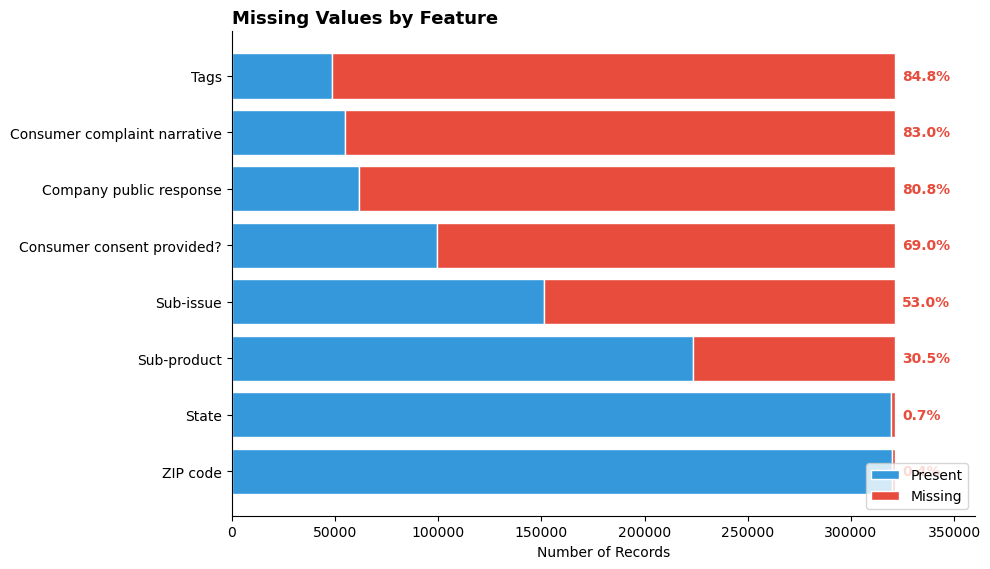


================== Missing Values Summary ==================

                     Feature  Missing  Present  Missing (%)
                        Tags   272731    48699         84.8
Consumer complaint narrative   266691    54739         83.0
     Company public response   259597    61833         80.8
  Consumer consent provided?   221797    99633         69.0
                   Sub-issue   170355   151075         53.0
                 Sub-product    98075   223355         30.5
                       State     2145   319285          0.7
                    ZIP code     1363   320067          0.4
            Timely response?        0   321430          0.0
               Date received        0   321430          0.0
                       Issue        0   321430          0.0
                Complaint ID        0   321430          0.0
                     Company        0   321430          0.0
          Consumer disputed?        0   321430          0.0
               Submitted via        0

In [12]:
# exploring missing values across features to identify potential data quality issues 

# calculate missing values
missing = pd.DataFrame({
    'Feature': df_raw.columns,
    'Missing': df_raw.isnull().sum().values,
    'Present': df_raw.notnull().sum().values,
    'Missing (%)': (df_raw.isnull().mean().values * 100).round(1)
}).sort_values('Missing (%)', ascending=True).reset_index(drop=True)

# only plot features with missing values
missing_only = missing[missing['Missing'] > 0].copy()

# visualize missing values with a horizontal bar chart
if len(missing_only) > 0:
    fig, ax = plt.subplots(figsize=(10, len(missing_only) * 0.6 + 1))
    
    y_pos = range(len(missing_only))
    
    # Stacked bars: present (blue) + missing (red)
    ax.barh(y_pos, missing_only['Present'].values, color='#3498db', label='Present', edgecolor='white')
    ax.barh(y_pos, missing_only['Missing'].values, left=missing_only['Present'].values, color='#e74c3c', label='Missing', edgecolor='white')
    
    # Labels
    ax.set_yticks(y_pos)
    ax.set_yticklabels(missing_only['Feature'].values, fontsize=10)
    
    # Percentage annotations
    for i, (feat, pct) in enumerate(zip(missing_only['Feature'], missing_only['Missing (%)'])):
        ax.text(len(df_raw) + len(df_raw) * 0.01, i, f'{pct}%', va='center', fontsize=10, fontweight='bold', color='#e74c3c')
    
    ax.set_title('Missing Values by Feature', fontsize=13, fontweight='bold', loc='left')
    ax.legend(loc='lower right', fontsize=10)
    ax.set_xlabel('Number of Records')
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlim(0, len(df_raw) * 1.12)
    
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")

# printing summary table
print("\n================== Missing Values Summary ==================\n")
print(missing.sort_values(by='Missing (%)', ascending=False).to_string(index=False))

**Findings & Comments:**

7 out of 18 features contain missing values, though no feature is fully empty. The three highest, `Tags` (84.8%), `Consumer complaint narrative` (83.0%), and `Company public response` (80.8%), are missing by design rather than data quality failure: `Tags` apply only to specific consumer groups (older Americans, servicemembers), narratives require explicit consumer opt-in, and public responses are optional for companies. `Consumer consent provided?` (69.0%) is missing for complaints received before the consent mechanism was introduced. `Sub-issue` (53.0%) and `Sub-product` (30.5%) are structurally absent because not all products and issues have corresponding sub-categories. `State` (0.7%) and `ZIP code` (0.4%) show minimal missingness. Importantly, all missing values carry potential predictive signal (e.g., the absence of a tag indicates a non-vulnerable consumer) and will be encoded explicitly rather than dropped.

## 2.2 Check Duplicates

In [13]:
# Checking for duplicate rows

n_duplicates = df_raw.duplicated().sum()
print(f"Duplicate rows: {n_duplicates:,} ({n_duplicates / len(df_raw):.2%})")

Duplicate rows: 0 (0.00%)


**Findings & Comments:** Since there are no duplicates found, no deduplication required.

## 2.3 Target Variable Exploration (`Consumer disputed?`)

==== Target Variable Distribution ==== 

Absolute counts:
Consumer disputed?
No     257436
Yes     63994
Name: count, dtype: int64

Proportions:
Consumer disputed?
No     0.801
Yes    0.199
Name: proportion, dtype: float64


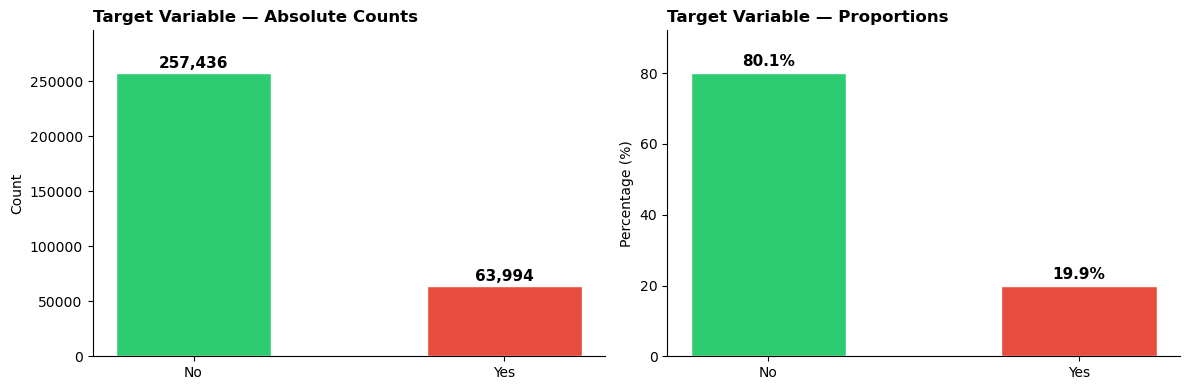

Imbalance ratio: 4.0 : 1 (No : Yes)


In [14]:
# Exploring the target variable distribution

print("==== Target Variable Distribution ==== \n")
print(f"Absolute counts:\n{df_raw['Consumer disputed?'].value_counts()}")
print(f"\nProportions:\n{df_raw['Consumer disputed?'].value_counts(normalize=True).round(3)}")

# Visualizing the target variable distribution with both absolute counts and proportions side by side
target = df_raw['Consumer disputed?'].value_counts()
target_pct = df_raw['Consumer disputed?'].value_counts(normalize=True) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# left chart: Absolute counts
colors = ['#2ecc71', '#e74c3c']
bars = ax1.bar(target.index, target.values, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, target.values):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2000,
             f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax1.set_title('Target Variable — Absolute Counts', fontsize=12, fontweight='bold', loc='left')
ax1.set_ylabel('Count')
ax1.spines[['top', 'right']].set_visible(False)
ax1.set_ylim(0, target.max() * 1.15)

# right chart: Proportions
bars2 = ax2.bar(target_pct.index, target_pct.values, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars2, target_pct.values):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax2.set_title('Target Variable — Proportions', fontsize=12, fontweight='bold', loc='left')
ax2.set_ylabel('Percentage (%)')
ax2.spines[['top', 'right']].set_visible(False)
ax2.set_ylim(0, target_pct.max() * 1.15)

plt.tight_layout()
plt.show()

# printing the imbalance ratio
majority = target.max()
minority = target.min()
print(f"Imbalance ratio: {majority / minority:.1f} : 1 (No : Yes)")

**Findings & Comments:**

The target variable is binary with no N/A values, thus, the dataset is pre-cleaned for the dispute outcome. 80.1% of complaints (257,436) were not disputed, while 19.9% (63,994) were disputed by consumers
which introduces an imbalance ratio of 4:1 (No:Yes). Thus, a naive model predicting "No" for every case would achieve ~80% accuracy while catching zero actual disputes. This imbalance must be addressed during modeling in chapter 4 (Q2).

## 2.4 Cardinality check

In [15]:
# Exploring feature cardinality to identify high-cardinality categorical features that may require special handling during preprocessing

features = [col for col in df_raw.columns if col not in ['Consumer disputed?', 'Complaint ID']]

cardinality = pd.DataFrame({
    'Feature': features,
    'Unique Values': [df_raw[col].nunique() for col in features],
    'Missing (%)': [(df_raw[col].isna().mean() * 100).round(1) for col in features],
    'Sample Values': [df_raw[col].dropna().unique()[:3].tolist() for col in features]
}).sort_values('Unique Values', ascending=False).reset_index(drop=True)

# constructing cardinality category

def classify_cardinality(n):
    if n <= 2:
        return 'Binary'
    elif n <= 15:
        return 'Low'
    elif n <= 100:
        return 'Medium'
    else:
        return 'High'

cardinality['Cardinality'] = cardinality['Unique Values'].apply(classify_cardinality)
cardinality = cardinality[['Cardinality', 'Feature', 'Unique Values', 'Missing (%)', 'Sample Values']]
cardinality

,Cardinality,Feature,Unique Values,Missing (%),Sample Values
0,High,Consumer complaint narrative,53697,83.0,[I have filed numerous complaints in an attemp...
1,High,ZIP code,22664,0.4,"[04419, 33615, 27520]"
2,High,Company,3250,0.0,"[Ocwen Financial Corporation, WELLS FARGO & CO..."
3,High,Date sent to company,803,0.0,"[2015-12-23, 2015-05-29, 2015-07-14]"
4,High,Date received,730,0.0,"[2015-12-17, 2015-05-27, 2015-07-13]"
5,Medium,Issue,92,0.0,"[Loan modification,collection,foreclosure, Com..."
6,Medium,State,62,0.7,"[ME, FL, NC]"
7,Medium,Sub-issue,58,53.0,"[Frequent or repeated calls, Debt is not mine,..."
8,Medium,Sub-product,46,30.5,"[Other mortgage, FHA mortgage, Other (i.e. pho..."
9,Low,Product,12,0.0,"[Mortgage, Debt collection, Bank account or se..."


**Findings & Comments:**

Cardinality varies widely across features. Five high-cardinality features, `Consumer complaint narrative` (free text, 53K unique values), `ZIP code` (22K), `Company` (3,250), and two date fields (730 to 803 unique values), cannot be one-hot encoded directly. The narrative column will be reduced to derived signals (e.g., binary presence flag, length, keyword counts), dates will be engineered into numeric features, and `Company` and `ZIP code` will require frequency or target encoding to keep the feature space manageable. Four medium-cardinality features, `Issue` (92), `State` (62), `Sub-issue` (58), and `Sub-product` (46), will likely require grouping of rare categories or alternative encoding strategies. Six low-cardinality features, `Product` (12), `Company public response` (10), `Submitted via` (6), `Company response to consumer` (5), `Consumer consent provided?` (4), and `Tags` (3), are well suited for simpler encoding after imputing missing values as a distinct `"Missing"` category. Finally, `Timely response?` is the only binary feature and requires a simple Yes/No to 1/0 mapping.

## 2.5 Date features

--- Date Range ---
Date received:        2014-01-01 to 2015-12-31
Date sent to company: 2013-12-31 to 2018-03-16

--- Response Delay (days) ---
count    321430.0
mean          3.8
std          12.2
min          -1.0
25%           0.0
50%           0.0
75%           5.0
max        1270.0
Name: response_delay, dtype: float64

Negative delays: 3,906 (1.2%)
Same-day forwarding: 161,024 (50.1%)
Delays > 30 days: 6,348 (2.0%)


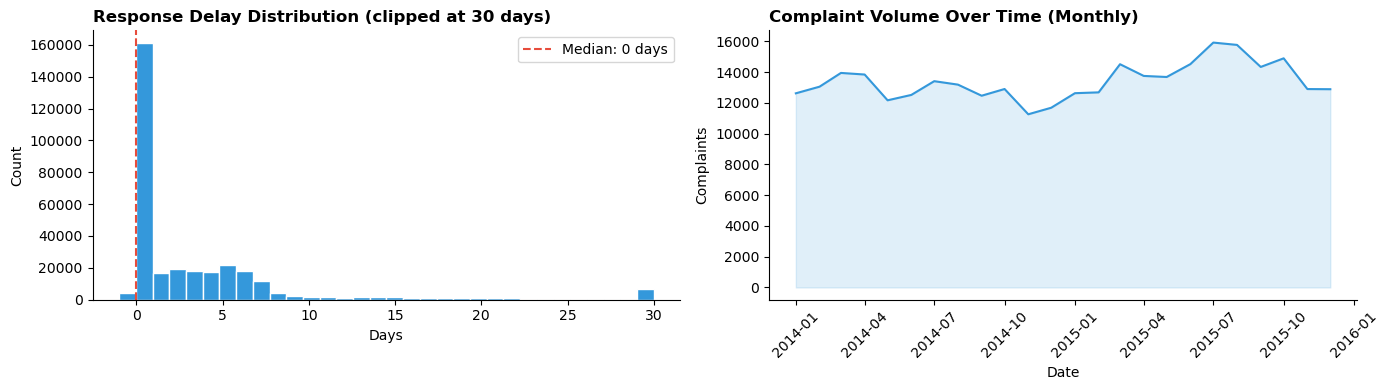

In [16]:
# Exploring date features to understand the time range of the complaints and analyze response delays 

df_dates = df_raw[['Date received', 'Date sent to company']].copy()
df_dates['Date received'] = pd.to_datetime(df_dates['Date received'])
df_dates['Date sent to company'] = pd.to_datetime(df_dates['Date sent to company'])

# Date range
print("--- Date Range ---")
print(f"Date received:        {df_dates['Date received'].min().date()} to {df_dates['Date received'].max().date()}")
print(f"Date sent to company: {df_dates['Date sent to company'].min().date()} to {df_dates['Date sent to company'].max().date()}")

# Response delay
df_dates['response_delay'] = (df_dates['Date sent to company'] - df_dates['Date received']).dt.days

print(f"\n--- Response Delay (days) ---")
print(df_dates['response_delay'].describe().round(1))
print(f"\nNegative delays: {(df_dates['response_delay'] < 0).sum():,} ({(df_dates['response_delay'] < 0).mean():.1%})")
print(f"Same-day forwarding: {(df_dates['response_delay'] == 0).sum():,} ({(df_dates['response_delay'] == 0).mean():.1%})")
print(f"Delays > 30 days: {(df_dates['response_delay'] > 30).sum():,} ({(df_dates['response_delay'] > 30).mean():.1%})")

# Visualize distribution (clipped for readability)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Left: Response delay distribution (clipped at 30 days)
delay_clipped = df_dates['response_delay'].clip(-1, 30)
ax1.hist(delay_clipped, bins=32, color='#3498db', edgecolor='white')
ax1.axvline(x=df_dates['response_delay'].median(), color='#e74c3c', linestyle='--', linewidth=1.5, label=f"Median: {df_dates['response_delay'].median():.0f} days")
ax1.set_title('Response Delay Distribution (clipped at 30 days)', fontsize=12, fontweight='bold', loc='left')
ax1.set_xlabel('Days')
ax1.set_ylabel('Count')
ax1.legend(fontsize=10)
ax1.spines[['top', 'right']].set_visible(False)

# Right: Complaints over time (monthly)
monthly = df_dates.groupby(df_dates['Date received'].dt.to_period('M')).size()
monthly.index = monthly.index.to_timestamp()
ax2.plot(monthly.index, monthly.values, color='#3498db', linewidth=1.5)
ax2.fill_between(monthly.index, monthly.values, alpha=0.15, color='#3498db')
ax2.set_title('Complaint Volume Over Time (Monthly)', fontsize=12, fontweight='bold', loc='left')
ax2.set_xlabel('Date')
ax2.set_ylabel('Complaints')
ax2.spines[['top', 'right']].set_visible(False)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Findings & Comments:**

Complaints were received between 2014-01-01 and 2015-12-31, spanning a two-year window. Notably, `Date sent to company` extends to 2018-03-16, meaning some complaints took years to be forwarded. The response delay distribution is heavily right-skewed: 50.1% of complaints are forwarded the same day (median of 0 days), but the mean rises to 3.8 days due to extreme outliers (maximum of 1,270 days), with the 75th percentile at just 5 days. A total of 3,906 rows (1.2%) show a negative delay of -1 day, most likely caused by timezone differences between complaint receipt and company forwarding timestamps. These will be clipped to 0 during feature engineering. Approximately 2.0% of complaints have delays exceeding 30 days. Tree-based models are robust to such outliers, but capping may be considered for Logistic Regression. Complaint volume is relatively stable across the observation period at roughly 12,000 to 15,000 complaints per month, with a slight dip around early 2015 and no major seasonal spikes, suggesting that temporal seasonality is unlikely to be a strong predictor.

From a feature engineering perspective, three features will be derived from the date columns: `response_delay_days` as the primary numeric signal (clipped at 0), `day_of_week` extracted from `Date received` to test whether weekday versus weekend submissions behave differently, and `received_year` to capture any year-level trend across the 2014 to 2015 period. Raw date columns will be dropped after engineering.

## 2.6 Univariate distributions

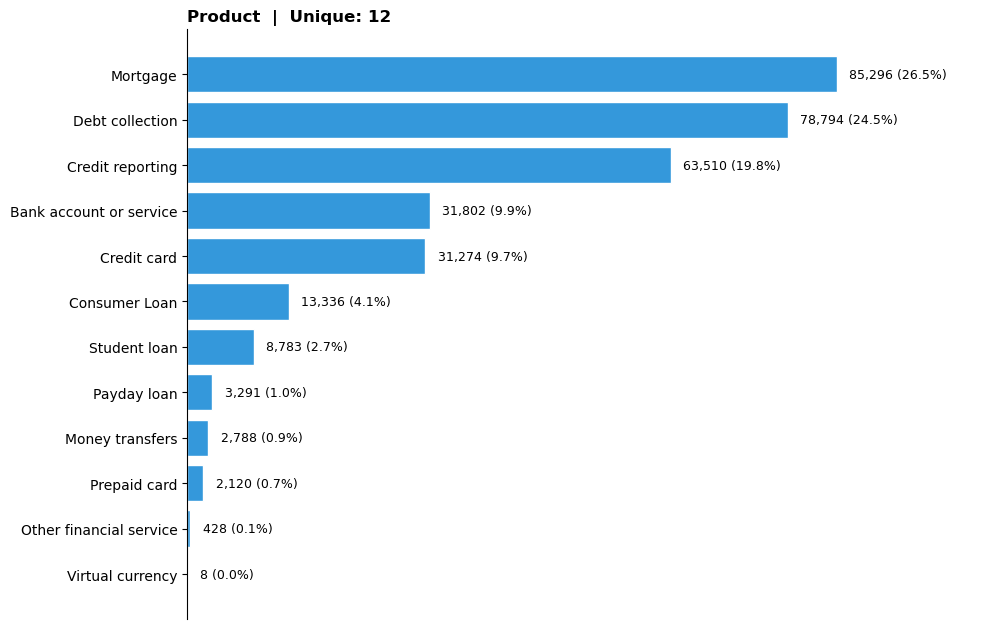

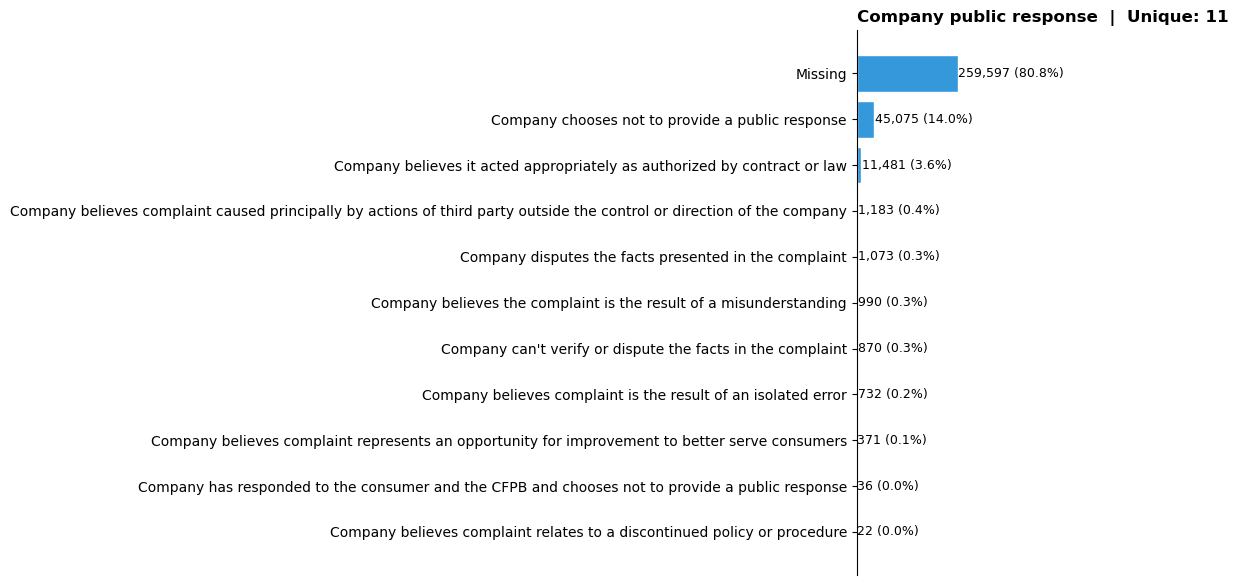

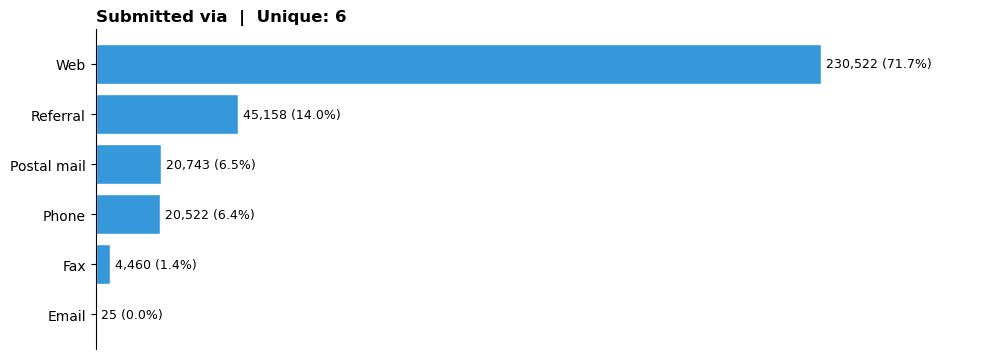

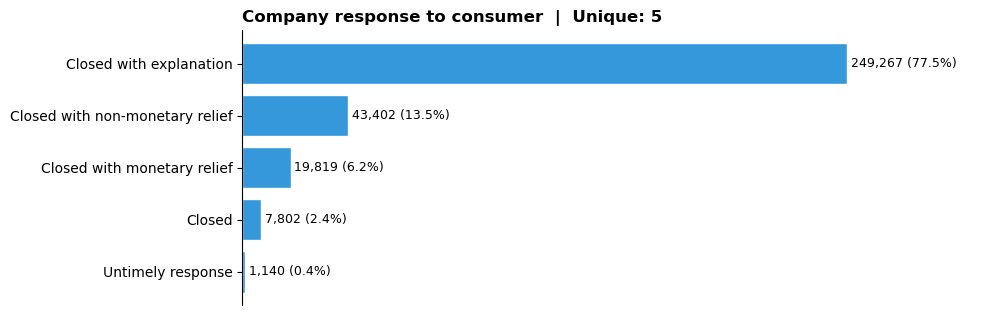

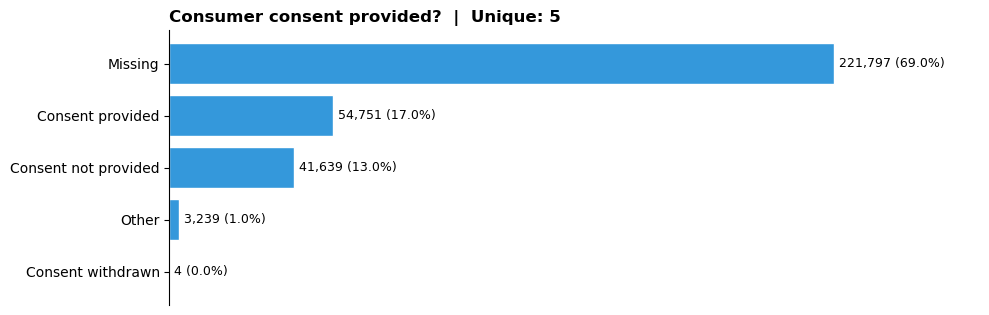

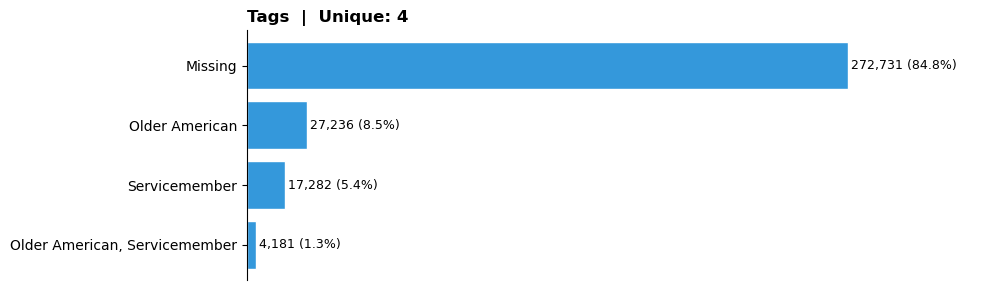

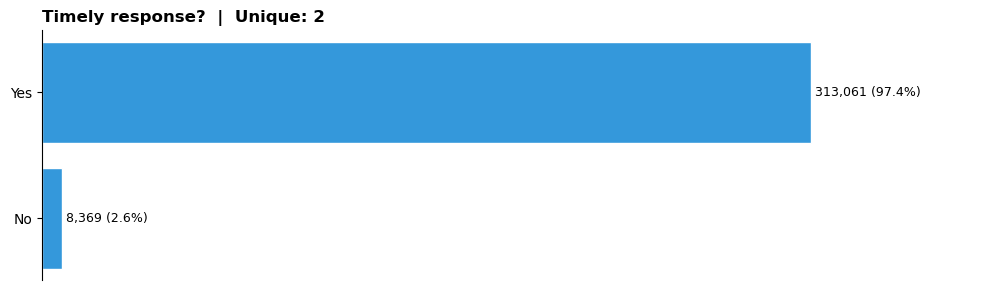

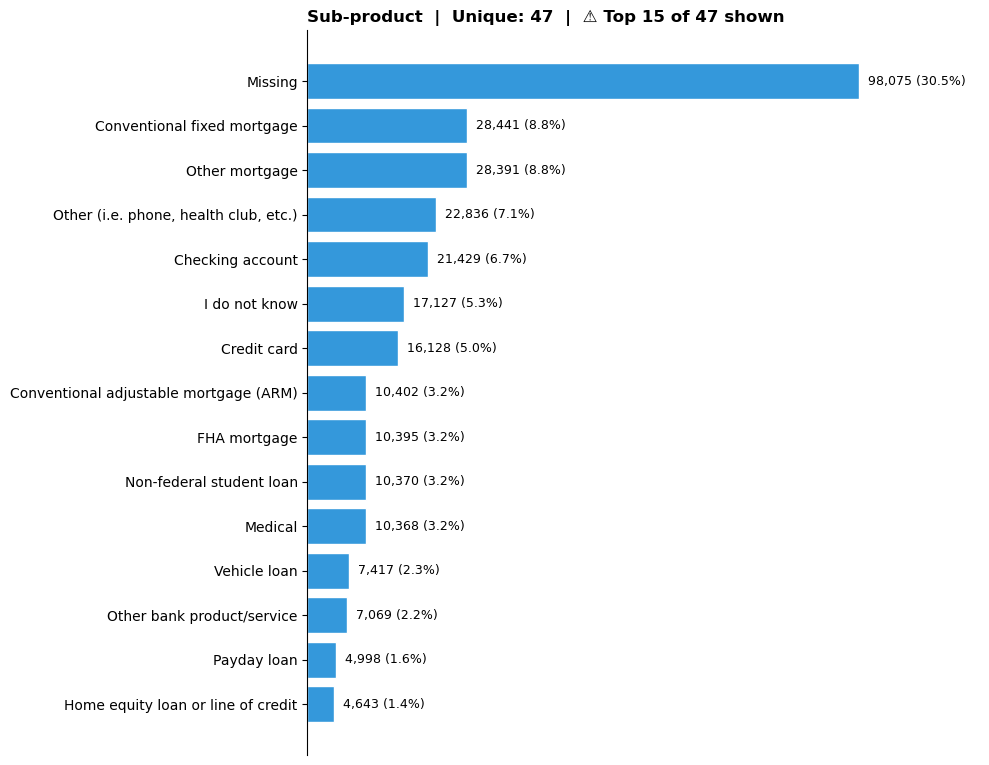

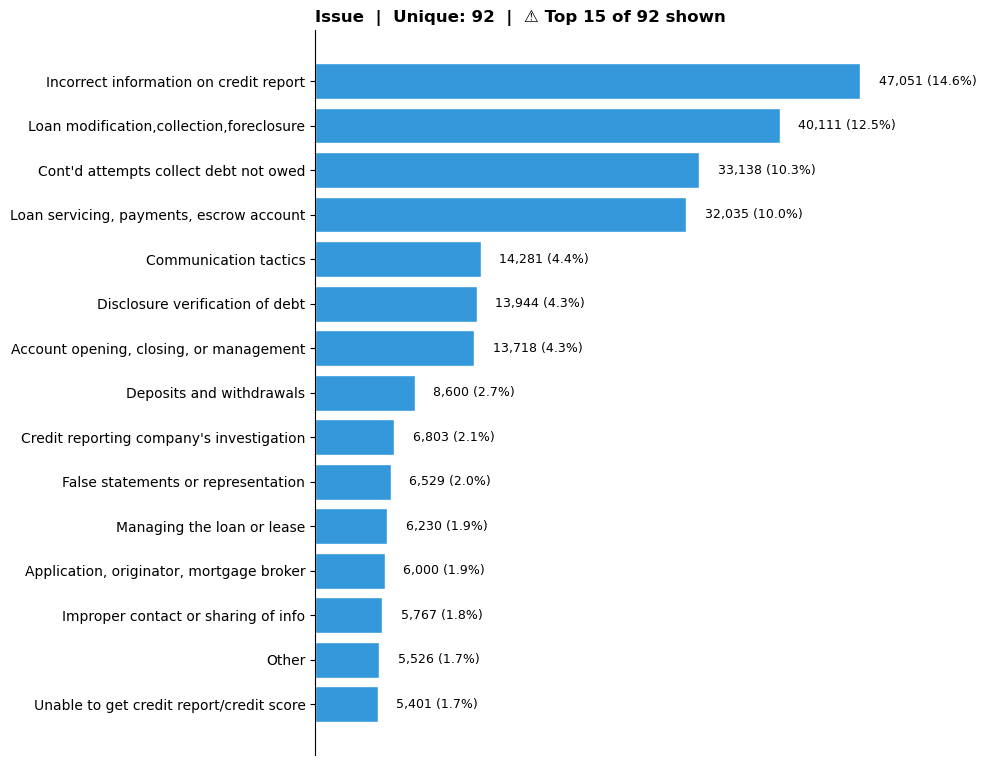

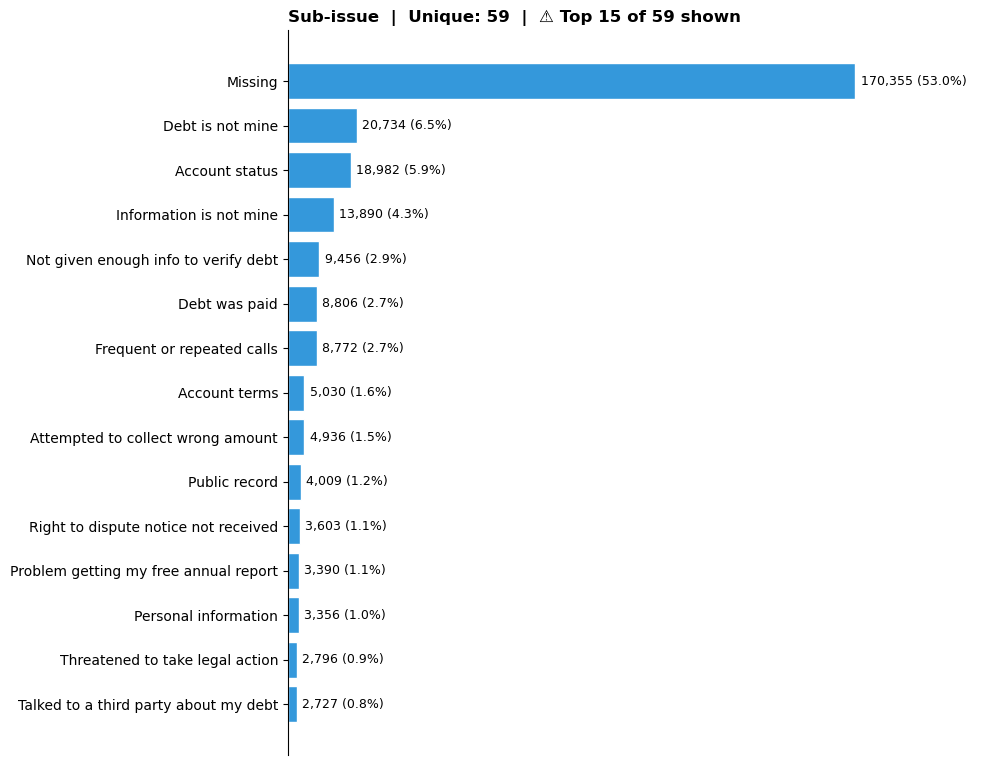

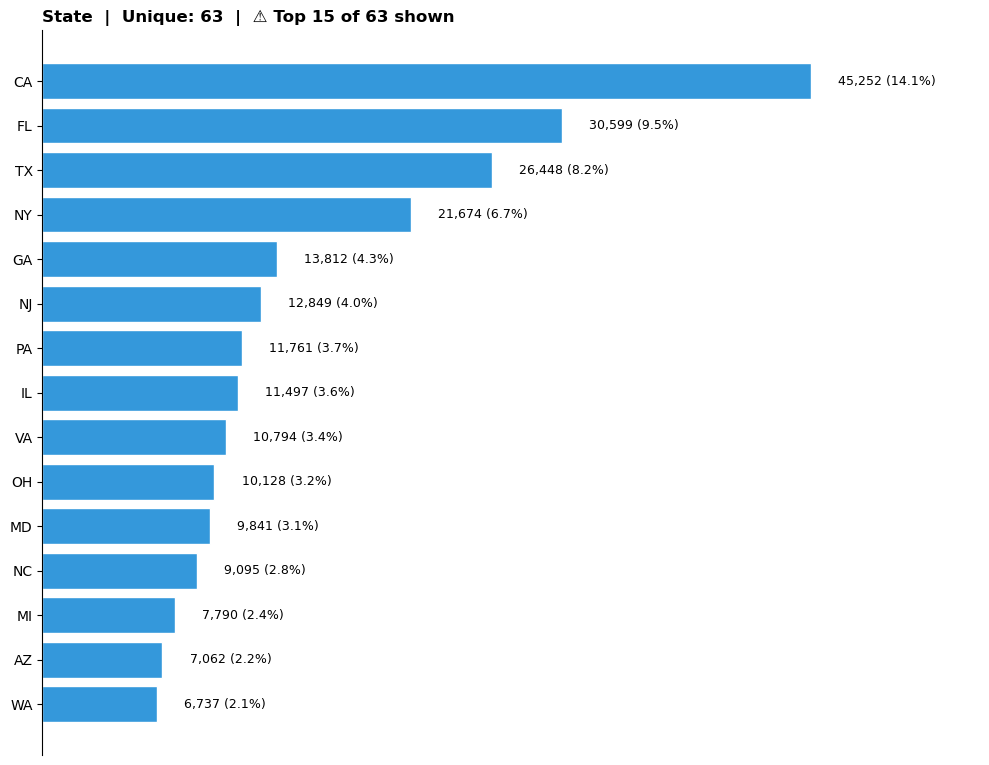

In [17]:
# exploring categorical features with low to medium cardinality by visualizing their value distributions to identify potential patterns

low_med_features = ['Product', 'Company public response', 'Submitted via',
                    'Company response to consumer', 'Consumer consent provided?',
                    'Tags', 'Timely response?', 'Sub-product', 'Issue', 'Sub-issue', 'State']

for col in low_med_features:
    counts = df_raw[col].value_counts(dropna=False)
    n_unique = len(counts)
    
    # capping at top 15 for readability
    max_bars = 15
    if n_unique > max_bars:
        plot_data = counts.head(max_bars)
        truncated = True
    else:
        plot_data = counts
        truncated = False
    
    # reversing so largest is on top
    plot_data = plot_data.iloc[::-1]
    labels = [str(x) if pd.notna(x) else 'Missing' for x in plot_data.index]
    
    fig_height = max(3, len(plot_data) * 0.45 + 1)
    fig, ax = plt.subplots(figsize=(10, fig_height))
    
    bars = ax.barh(labels, plot_data.values, color='#3498db', edgecolor='white')
    
    # Count + percentage annotations
    total = len(df_raw)
    for bar, val in zip(bars, plot_data.values):
        ax.text(val + total * 0.005, bar.get_y() + bar.get_height() / 2,
                f'{val:,} ({val/total:.1%})', va='center', fontsize=9)
    
    # Title
    title = f'{col}  |  Unique: {n_unique}'
    if truncated:
        title += f'  |  ⚠️ Top {max_bars} of {n_unique} shown'
    ax.set_title(title, fontsize=12, fontweight='bold', loc='left')
    ax.xaxis.set_visible(False)
    ax.spines[['top', 'right', 'bottom']].set_visible(False)
    ax.set_xlim(0, plot_data.max() * 1.22)
    
    plt.tight_layout()
    plt.show()
    print()

**Findings & Comments:**

- `Product` is dominated by three categories: `Mortgage` (26.5%), `Debt collection` (24.5%), and `Credit reporting` (19.8%), which together account for roughly 71% of all complaints. `Virtual currency` and `Other financial service` are negligible at less than 0.1% each.
- `Company public response` is missing for 80.8% of complaints, as most companies choose not to issue a public-facing statement. Among those that do, "Company chooses not to provide a public response" (14.0%) and "Company believes it acted appropriately" (3.6%) are the most common categories.
- `Submitted via` is overwhelmingly dominated by `Web` at 71.7%, followed by `Referral` (14.0%), while `Email` is virtually unused (0.0%). This distribution provides important context for testing the digital channels assumption in Q1.
- `Company response to consumer` is highly concentrated: "Closed with explanation" accounts for 77.5% of all responses, while only 6.2% are closed with monetary relief and 0.4% are flagged as untimely. The dominance of a single response category means the model's ability to distinguish escalation risk will depend on capturing subtle differences within that majority class.
- `Consumer consent provided?` is missing for 69.0% of complaints, corresponding to cases that predate the introduction of the consent mechanism. Among the remainder, consent provided (17.0%) slightly exceeds consent not provided (13.0%).
- `Tags` is missing for 84.8% of complaints, which is expected since tags apply only to specific consumer groups: Older Americans (8.5%) and Servicemembers (5.4%).
- `Timely response?` is extremely skewed, with 97.4% of responses classified as timely and only 2.6% as late. Despite the low variance, untimely responses could still be a strong predictor of dispute escalation given the signal carried by rare events.
- `Sub-product` is missing for 30.5% of complaints, as not all products have sub-categories. Among those present, `Conventional fixed mortgage` (8.8%) and `Other mortgage` (8.8%) are the most frequent values.
- `Issue` shows moderate concentration: the top three categories, "Incorrect information on credit report" (14.6%), "Loan modification/foreclosure" (12.5%), and "Continued attempts to collect debt not owed" (10.3%), together account for approximately 37% of all complaints.
- `Sub-issue` is missing for 53.0% of complaints. Among those reported, "Debt is not mine" (6.5%) and "Account status" (5.9%) are the most common sub-categories.
- `State` is led by California (14.1%), Florida (9.5%), and Texas (8.2%), largely reflecting population size. The feature contains 63 unique values including U.S. territories.

## 2.7 Create working DataFrame

In [18]:
# Initial preprocessing for modeling
df = df_raw.copy()

# Encode target
df['Consumer disputed?'] = df['Consumer disputed?'].map({'Yes': 1, 'No': 0})

# Drop Complaint ID (unique identifier, no predictive value)
df = df.drop(columns=['Complaint ID'])

# Rename columns for readability
df.columns = (df.columns
              .str.strip()
              .str.replace(' ', '_')
              .str.replace('?', '', regex=False)
              .str.replace('-', '_')
              .str.lower())

print(f"Working DataFrame shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")
print(f"\nTarget distribution:\n{df['consumer_disputed'].value_counts()}")

Working DataFrame shape: (321430, 17)

Columns:
['date_received', 'product', 'sub_product', 'issue', 'sub_issue', 'consumer_complaint_narrative', 'company_public_response', 'company', 'state', 'zip_code', 'tags', 'consumer_consent_provided', 'submitted_via', 'date_sent_to_company', 'company_response_to_consumer', 'timely_response', 'consumer_disputed']

Target distribution:
consumer_disputed
0    257436
1     63994
Name: count, dtype: int64


**Note:**
This working dataframe is used for exploratory analysis only. All feature engineering (binary flags, encoding, imputation, date transformations) is implemented in a standalone `feature_engineering()` function in Q2, ensuring full reproducibility on unseen data. The target variable is already encoded as 0/1 and requires no further action. Binary features such as `timely_response` will be mapped to 1/0, and a binary flag for narrative presence will be derived from `consumer_complaint_narrative` before dropping the raw text. Categorical features will be imputed with `"Missing"` as a distinct category, then encoded using smoothed target encoding to handle the wide range of cardinality across features (from 3 unique values for `Tags` to 3,250+ for `Company`) without creating an impractically large feature space. Date features will be used to engineer `response_lag_days`, `received_year`, and `day_of_week`, with negative delays clipped to 0 and raw date columns dropped afterward.

# 3. Question 1: EDA & Business Insights

In the first part of this section (3.1) I will investigate the following executive assumptions made by Meridian driving customer disputes. I will use EDA, analyzing the total disputes by the relevant driver and perform a short Chi-Square test to validate/disprove statistically significant influence:

- (a) Chief Risk Officer: Certain products are associated with more negative outcomes: Internal reports indicate that credit card products were responsible for most unresolved cases
- (b) Head of Digital Experience: Complaints submitted through digital channels escalate more frequently than those submitted via traditional channels
- (c) Compliance Director: Response time varies across states, thus, raising the risk of regulatory scrutiny and potential penalties, i.e., regional differences may influence response time

Additionally (3.2), I will further investigate the following three hypotheses driving customer disputes and deriving managerial insights:

- (d) Certain resolution types (`company_response_to_consumer`) yield a higher dispute rate
- (e) Issuing a public response (`company_public_response`) leads to fewer disputes
- (f) Certain types of consumers (`tags`) are more likely to dispute complaints

**Summary of the findings for Question 1:**

All three executive assumptions were tested using statistical evidence:

| Assumption | Claim | Verdict | Statistical Test |
|---|---|---|---|
| (a) CRO | Credit cards cause most disputes | Not supported | χ² = 1,640.3, p < 0.001 |
| (b) Head of Digital | Digital channels escalate more | Supported | χ² = 1,459.2, p < 0.001 |
| (c) Compliance Director | Response times vary across states | Supported | χ² = 426.3, p < 0.001; H = 836.6, p < 0.001 |

In summary, the data reveals that Mortgage, not Credit card, is the primary driver of dispute escalation both by rate and volume. Digital channels do escalate more frequently, with Web submissions showing a 21.6% dispute rate versus 15.6% for traditional channels. Regional variation in both response times and dispute rates is statistically significant. However, response speed alone does not fully explain escalation, suggesting that the quality, clarity, and effectiveness of the response likely play a more important role.

**Additional managerial insights from exploratory analysis (Question 1.2):**

Beyond the executive assumptions, several additional factors were identified that provide valuable insights for improving complaint management and reducing escalation risk:

First, company response type is one of the strongest drivers of escalation. Complaints closed with monetary relief show substantially lower dispute rates compared to explanation-only closures. In contrast, responses perceived as incomplete or procedural are associated with significantly higher escalation rates. This suggests that the substance and clarity of the resolution are critical in determining whether customers accept the outcome.

Second, public-facing company responses are associated with lower dispute rates. When companies provide transparent public responses, dispute rates tend to be lower compared to cases where no public response is provided. This indicates that transparency and accountability may increase customer trust and reduce escalation likelihood. Public responses may also reflect more structured and carefully handled complaint resolution processes.

Third, customer vulnerability indicators (consumer tags) are associated with higher escalation risk. Complaints submitted by vulnerable groups, including Older Americans and Servicemembers, show consistently higher dispute rates compared to untagged customers. This suggests that vulnerable populations may require more personalized handling, clearer communication, or specialized support. Improved segmentation and targeted intervention strategies could reduce escalation risk and improve regulatory compliance, as regulators often emphasize fair treatment of vulnerable customer groups.

## 3.1 Question 1.1: Investigating executive assumptions

### 3.1.1 Claim a): Disputes & dispute rate by product

In [19]:
# investigating assumption (a) that CRO claims that certain products, especially credit card products, are responsible 
# for most unresolved (disputed) cases by analyzing the dispute rate and volume by product category

# calculating dispute rate and volume by product
product_stats = (df.groupby('product')['consumer_disputed']
                 .agg(['mean', 'sum', 'count'])
                 .rename(columns={'mean': 'dispute_rate', 'sum': 'n_disputes', 'count': 'n_complaints'})
                 .sort_values('dispute_rate', ascending=False))

# calculating share of total disputes
product_stats['share_of_disputes'] = (product_stats['n_disputes'] / product_stats['n_disputes'].sum() * 100).round(1)
product_stats['dispute_rate_pct'] = (product_stats['dispute_rate'] * 100).round(1)

print("--- Dispute Rate & Volume by Product ---")
print(product_stats[['n_complaints', 'n_disputes', 'dispute_rate_pct', 'share_of_disputes']])


--- Dispute Rate & Volume by Product ---
                         n_complaints  n_disputes  dispute_rate_pct  \
product                                                               
Virtual currency                    8           5              62.5   
Mortgage                        85296       20170              23.6   
Consumer Loan                   13336        3017              22.6   
Credit card                     31274        6664              21.3   
Bank account or service         31802        6266              19.7   
Student loan                     8783        1708              19.4   
Other financial service           428          80              18.7   
Debt collection                 78794       14543              18.5   
Credit reporting                63510       10355              16.3   
Payday loan                      3291         522              15.9   
Money transfers                  2788         387              13.9   
Prepaid card                     212

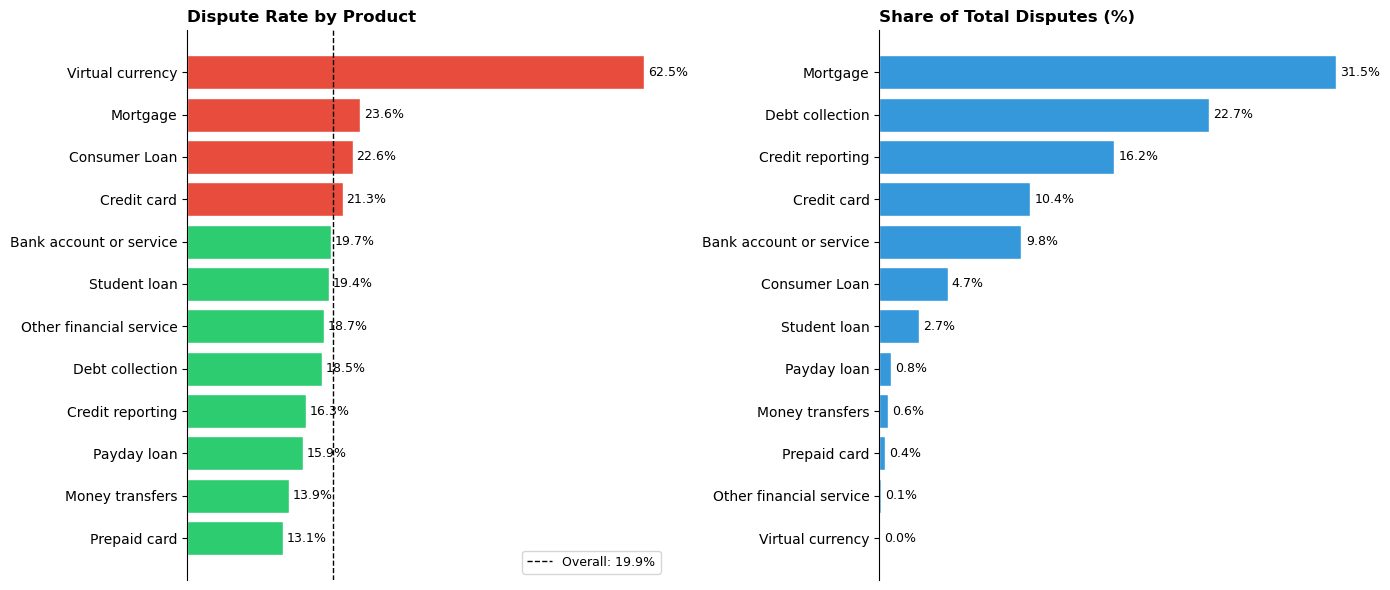

In [20]:
# visualizing dispute rate and share of disputes by product 

product_sorted = product_stats.sort_values('dispute_rate')
overall_rate = df['consumer_disputed'].mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: Dispute rate by product
colors_rate = ['#e74c3c' if r > overall_rate else '#2ecc71' for r in product_sorted['dispute_rate']]
ax1.barh(product_sorted.index, product_sorted['dispute_rate'], color=colors_rate, edgecolor='white')
ax1.axvline(x=overall_rate, color='black', linestyle='--', linewidth=1, label=f'Overall: {overall_rate:.1%}')
for i, (rate, name) in enumerate(zip(product_sorted['dispute_rate'], product_sorted.index)):
    ax1.text(rate + 0.005, i, f'{rate:.1%}', va='center', fontsize=9)
ax1.set_title('Dispute Rate by Product', fontsize=12, fontweight='bold', loc='left')
ax1.legend(fontsize=9)
ax1.xaxis.set_visible(False)
ax1.spines[['top', 'right', 'bottom']].set_visible(False)

# Right: Share of total disputes
share_sorted = product_stats.sort_values('share_of_disputes')
ax2.barh(share_sorted.index, share_sorted['share_of_disputes'], color='#3498db', edgecolor='white')
for i, val in enumerate(share_sorted['share_of_disputes']):
    ax2.text(val + 0.3, i, f'{val}%', va='center', fontsize=9)
ax2.set_title('Share of Total Disputes (%)', fontsize=12, fontweight='bold', loc='left')
ax2.xaxis.set_visible(False)
ax2.spines[['top', 'right', 'bottom']].set_visible(False)

plt.tight_layout()
plt.show()

In [21]:
# performing a Chi-Squared test
contingency = pd.crosstab(df['product'], df['consumer_disputed'])
chi2, p_value, dof, expected = chi2_contingency(contingency)
print(f"\nChi-squared test: X² = {chi2:.1f}, p = {p_value:.2e}, dof = {dof}")


Chi-squared test: X² = 1640.3, p = 0.00e+00, dof = 11


**Comments:** 

**Verdict: Not supported.**

The CRO's claim that credit cards drive the most disputed cases is not confirmed by the data. The chi-squared test shows a statistically significant association between `product` and dispute outcome (X² = 1,640.3, p < 0.001, dof = 11), meaning product type does matter, but not in the way the CRO assumed.

In terms of dispute rate, Credit card ranks 4th at 21.3%, behind Virtual currency (62.5%, however, based on only 8 complaints and therefore not statistically meaningful), Mortgage (23.6%), and Consumer Loan (22.6%). All four exceed the overall dispute rate of 19.9%. However, credit cards are not the leading product.

More importantly, when looking at the share of total disputes, which is what the CRO's claim of "most unresolved cases" actually refers to, Mortgage dominates with 31.5% of all disputes (20,170 cases), followed by Debt collection at 22.7% (14,543 cases) and Credit reporting at 16.2% (10,355 cases). Credit cards account for only 10.4% of total disputes (6,664 cases), ranking 4th.

The CRO's perception may stem from credit cards being a high-visibility consumer product, but the data clearly shows that Mortgage is the primary driver of complaint escalation, both by rate and by volume. From a managerial perspective, escalation reduction efforts should prioritize mortgage servicing processes, followed by debt collection practices, rather than focusing disproportionately on credit cards.

Furthermore, the fact that the CRO based this claim on "anecdotal evidence from internal reports" raises concerns about the current reporting infrastructure. The disconnect between perception and data suggests that internal reports may be fragmented across product departments, potentially leading to incomplete or biased views of escalation patterns. I recommend consolidating complaint reporting into a single cross-product dashboard to ensure executive decisions are grounded in complete data rather than department-level anecdotes.

### 3.1.2 Claim b): Disputes & dispute rate by submission channel

In [22]:
# investigating assumption (b) that complaints submitted online escalate more frequently than traditional channels

# classifying channels as digital vs traditional
channel_map = {
    'Web': 'Digital',
    'Email': 'Digital',
    'Referral': 'Traditional',
    'Phone': 'Traditional',
    'Postal mail': 'Traditional',
    'Fax': 'Traditional'
}
df['channel_type'] = df['submitted_via'].map(channel_map)

# Dispute rate by individual channel
channel_stats = (df.groupby('submitted_via')['consumer_disputed']
                 .agg(['mean', 'sum', 'count'])
                 .rename(columns={'mean': 'dispute_rate', 'sum': 'n_disputes', 'count': 'n_complaints'})
                 .sort_values('dispute_rate', ascending=False))
channel_stats['dispute_rate_pct'] = (channel_stats['dispute_rate'] * 100).round(1)
channel_stats['n_complaints_pct'] = (channel_stats['n_complaints'] / channel_stats['n_complaints'].sum() * 100).round(1)

print("--- Dispute Rate by Submission Channel ---")
print(channel_stats[['n_complaints', 'n_disputes', 'dispute_rate_pct', 'n_complaints_pct']])

# Dispute rate by channel type (digital vs traditional)
type_stats = (df.groupby('channel_type')['consumer_disputed']
              .agg(['mean', 'sum', 'count'])
              .rename(columns={'mean': 'dispute_rate', 'sum': 'n_disputes', 'count': 'n_complaints'})
              .sort_values('dispute_rate', ascending=False))
type_stats['dispute_rate_pct'] = (type_stats['dispute_rate'] * 100).round(1)

print("\n--- Dispute Rate: Digital vs Traditional ---")
print(type_stats[['n_complaints', 'n_disputes', 'dispute_rate_pct']])


--- Dispute Rate by Submission Channel ---
               n_complaints  n_disputes  dispute_rate_pct  n_complaints_pct
submitted_via                                                              
Email                    25          10              40.0               0.0
Web                  230522       49785              21.6              71.7
Fax                    4460         945              21.2               1.4
Referral              45158        7297              16.2              14.0
Phone                 20522        2978              14.5               6.4
Postal mail           20743        2979              14.4               6.5

--- Dispute Rate: Digital vs Traditional ---
              n_complaints  n_disputes  dispute_rate_pct
channel_type                                            
Digital             230547       49795              21.6
Traditional          90883       14199              15.6


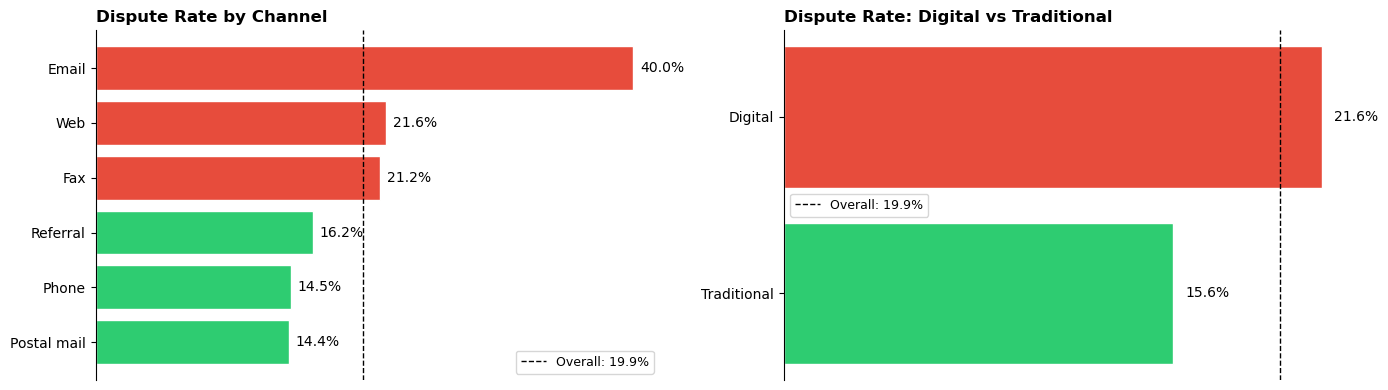

In [23]:
# visualizing dispute rate by channel and digital vs traditional

overall_rate = df['consumer_disputed'].mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Left: Dispute rate by individual channel
ch_sorted = channel_stats.sort_values('dispute_rate')
colors = ['#e74c3c' if r > overall_rate else '#2ecc71' for r in ch_sorted['dispute_rate']]
ax1.barh(ch_sorted.index, ch_sorted['dispute_rate'], color=colors, edgecolor='white')
ax1.axvline(x=overall_rate, color='black', linestyle='--', linewidth=1, label=f'Overall: {overall_rate:.1%}')
for i, rate in enumerate(ch_sorted['dispute_rate']):
    ax1.text(rate + 0.005, i, f'{rate:.1%}', va='center', fontsize=10)
ax1.set_title('Dispute Rate by Channel', fontsize=12, fontweight='bold', loc='left')
ax1.legend(fontsize=9)
ax1.xaxis.set_visible(False)
ax1.spines[['top', 'right', 'bottom']].set_visible(False)

# Right: Digital vs Traditional
tp_sorted = type_stats.sort_values('dispute_rate')
colors2 = ['#e74c3c' if r > overall_rate else '#2ecc71' for r in tp_sorted['dispute_rate']]
ax2.barh(tp_sorted.index, tp_sorted['dispute_rate'], color=colors2, edgecolor='white')
ax2.axvline(x=overall_rate, color='black', linestyle='--', linewidth=1, label=f'Overall: {overall_rate:.1%}')
for i, rate in enumerate(tp_sorted['dispute_rate']):
    ax2.text(rate + 0.005, i, f'{rate:.1%}', va='center', fontsize=10)
ax2.set_title('Dispute Rate: Digital vs Traditional', fontsize=12, fontweight='bold', loc='left')
ax2.legend(fontsize=9)
ax2.xaxis.set_visible(False)
ax2.spines[['top', 'right', 'bottom']].set_visible(False)

plt.tight_layout()
plt.show()

In [24]:
# Chi-squared test: submitted_via vs dispute
contingency_b = pd.crosstab(df['submitted_via'], df['consumer_disputed'])
chi2_b, p_value_b, dof_b, _ = chi2_contingency(contingency_b)
print(f"\nChi-squared test (by channel): X² = {chi2_b:.1f}, p = {p_value_b:.2e}, dof = {dof_b}")

# Chi-squared test: digital vs traditional
contingency_b2 = pd.crosstab(df['channel_type'], df['consumer_disputed'])
chi2_b2, p_value_b2, dof_b2, _ = chi2_contingency(contingency_b2)
print(f"Chi-squared test (digital vs traditional): X² = {chi2_b2:.1f}, p = {p_value_b2:.2e}, dof = {dof_b2}")


Chi-squared test (by channel): X² = 1596.3, p = 0.00e+00, dof = 5
Chi-squared test (digital vs traditional): X² = 1459.2, p = 0.00e+00, dof = 1


**Comments:**

**Verdict: Supported.**

The Head of Digital Experience's claim is confirmed by the data. Digital channels show a dispute rate of 21.6% compared to 15.6% for traditional channels, a 6 percentage point gap. The chi-squared test confirms this difference is statistically significant both at the individual channel level (X² = 1,596.3, p < 0.001, dof = 5) and when grouped as digital vs traditional (X² = 1,459.2, p < 0.001, dof = 1).

Looking at individual channels, Email has the highest dispute rate at 40.0%, though this is based on only 25 complaints and therefore unreliable. Web, the dominant digital channel with 230,522 complaints (71.7% of all submissions), has a dispute rate of 21.6%, above the 19.9% overall average. Fax also stands out at 21.2%, which is notable since it is classified as a traditional channel but behaves more like a digital one in terms of escalation.

On the traditional side, Referral (16.2%), Phone (14.5%), and Postal mail (14.4%) all sit well below the overall average.

However, it is important to note that the higher dispute rate for digital channels does not necessarily mean that digital submission causes escalation. On the one hand, one could argue that submitting complaints via digital channels is significantly easier to follow up on, faster and often lacks human interaction, therefore reducing the barrier to escalate complaints and resulting in more disputes per complaint. On the other hand, consumers who submit complaints online may be more digitally savvy, more proactive, or more engaged with the complaint process, making them more likely to follow through with a dispute regardless of the channel. Thus, this might be "only" a correlation, not a causal relationship.

Regardless of the underlying cause, these findings carry clear managerial implications. Since Web accounts for over 71% of all complaints and carries an above-average dispute rate, even small improvements in the digital complaint handling process could have a significant impact on overall escalation volumes. I would recommend three actions. First, the company should prioritize digital complaints in the triage queue, as they are statistically more likely to escalate. Second, they should invest in richer initial responses for web-submitted cases, e.g., providing more detailed explanations or attaching supporting documentation, to address the consumer's concern before it reaches the dispute stage. Lastly, they could consider implementing automated follow-up touchpoints (e.g., confirmation emails, status updates) for digitally submitted complaints, as the lack of human interaction in the digital channel may leave consumers feeling unheard, increasing their propensity to dispute.

### 3.1.3 Claim c): Response time, disputes & dispute rate by state

In [25]:
# investigating assumption (c) that response times vary significantly across states

# Calculate response delay
df['date_received'] = pd.to_datetime(df['date_received'])
df['date_sent_to_company'] = pd.to_datetime(df['date_sent_to_company'])
df['response_delay'] = (df['date_sent_to_company'] - df['date_received']).dt.days

# Response delay stats by state (drop missing states)
df_states = df[df['state'].notna()]

state_stats = (df_states.groupby('state')
               .agg(
                   n_complaints=('consumer_disputed', 'count'),
                   mean_delay=('response_delay', 'mean'),
                   median_delay=('response_delay', 'median'),
                   dispute_rate=('consumer_disputed', 'mean')
               )
               .sort_values('mean_delay', ascending=False))

state_stats['mean_delay'] = state_stats['mean_delay'].round(1)
state_stats['median_delay'] = state_stats['median_delay'].round(1)
state_stats['dispute_rate_pct'] = (state_stats['dispute_rate'] * 100).round(1)

print("--- Response Delay & Dispute Rate by State ---")
print(f"Top 10 slowest states:")
print(state_stats[['n_complaints', 'mean_delay', 'median_delay', 'dispute_rate_pct']].head(10))
print(f"\nTop 10 fastest states:")
print(state_stats[['n_complaints', 'mean_delay', 'median_delay', 'dispute_rate_pct']].tail(10))

print(f"\nRange of mean delay: {state_stats['mean_delay'].min()} to {state_stats['mean_delay'].max()} days")
print(f"Range of dispute rate: {state_stats['dispute_rate_pct'].min()}% to {state_stats['dispute_rate_pct'].max()}%")


--- Response Delay & Dispute Rate by State ---
Top 10 slowest states:
       n_complaints  mean_delay  median_delay  dispute_rate_pct
state                                                          
MP               11         9.2           1.0               0.0
PW                5         7.8           0.0              40.0
PR             1022         7.2           2.0              18.2
SD              472         5.8           0.0              14.8
TX            26448         4.9           0.0              17.6
KY             2403         4.5           0.0              19.2
NE             1023         4.5           0.0              21.0
NM             1629         4.4           1.0              15.8
AR             1451         4.4           1.0              17.6
LA             3371         4.3           0.0              18.0

Top 10 fastest states:
       n_complaints  mean_delay  median_delay  dispute_rate_pct
state                                                          
MN        

In [26]:
# Variation statistics
print(f"\n--- Variation Across States ---")
print(f"Mean delay — Std: {state_stats['mean_delay'].std():.2f} days, Variance: {state_stats['mean_delay'].var():.2f}")
print(f"Dispute rate — Std: {state_stats['dispute_rate_pct'].std():.2f}pp, Variance: {state_stats['dispute_rate_pct'].var():.2f}")
print(f"\nMean delay range: {state_stats['mean_delay'].min()} to {state_stats['mean_delay'].max()} days")
print(f"Dispute rate range: {state_stats['dispute_rate_pct'].min()}% to {state_stats['dispute_rate_pct'].max()}%")


--- Variation Across States ---
Mean delay — Std: 1.21 days, Variance: 1.46
Dispute rate — Std: 4.40pp, Variance: 19.33

Mean delay range: 0.9 to 9.2 days
Dispute rate range: 0.0% to 40.0%


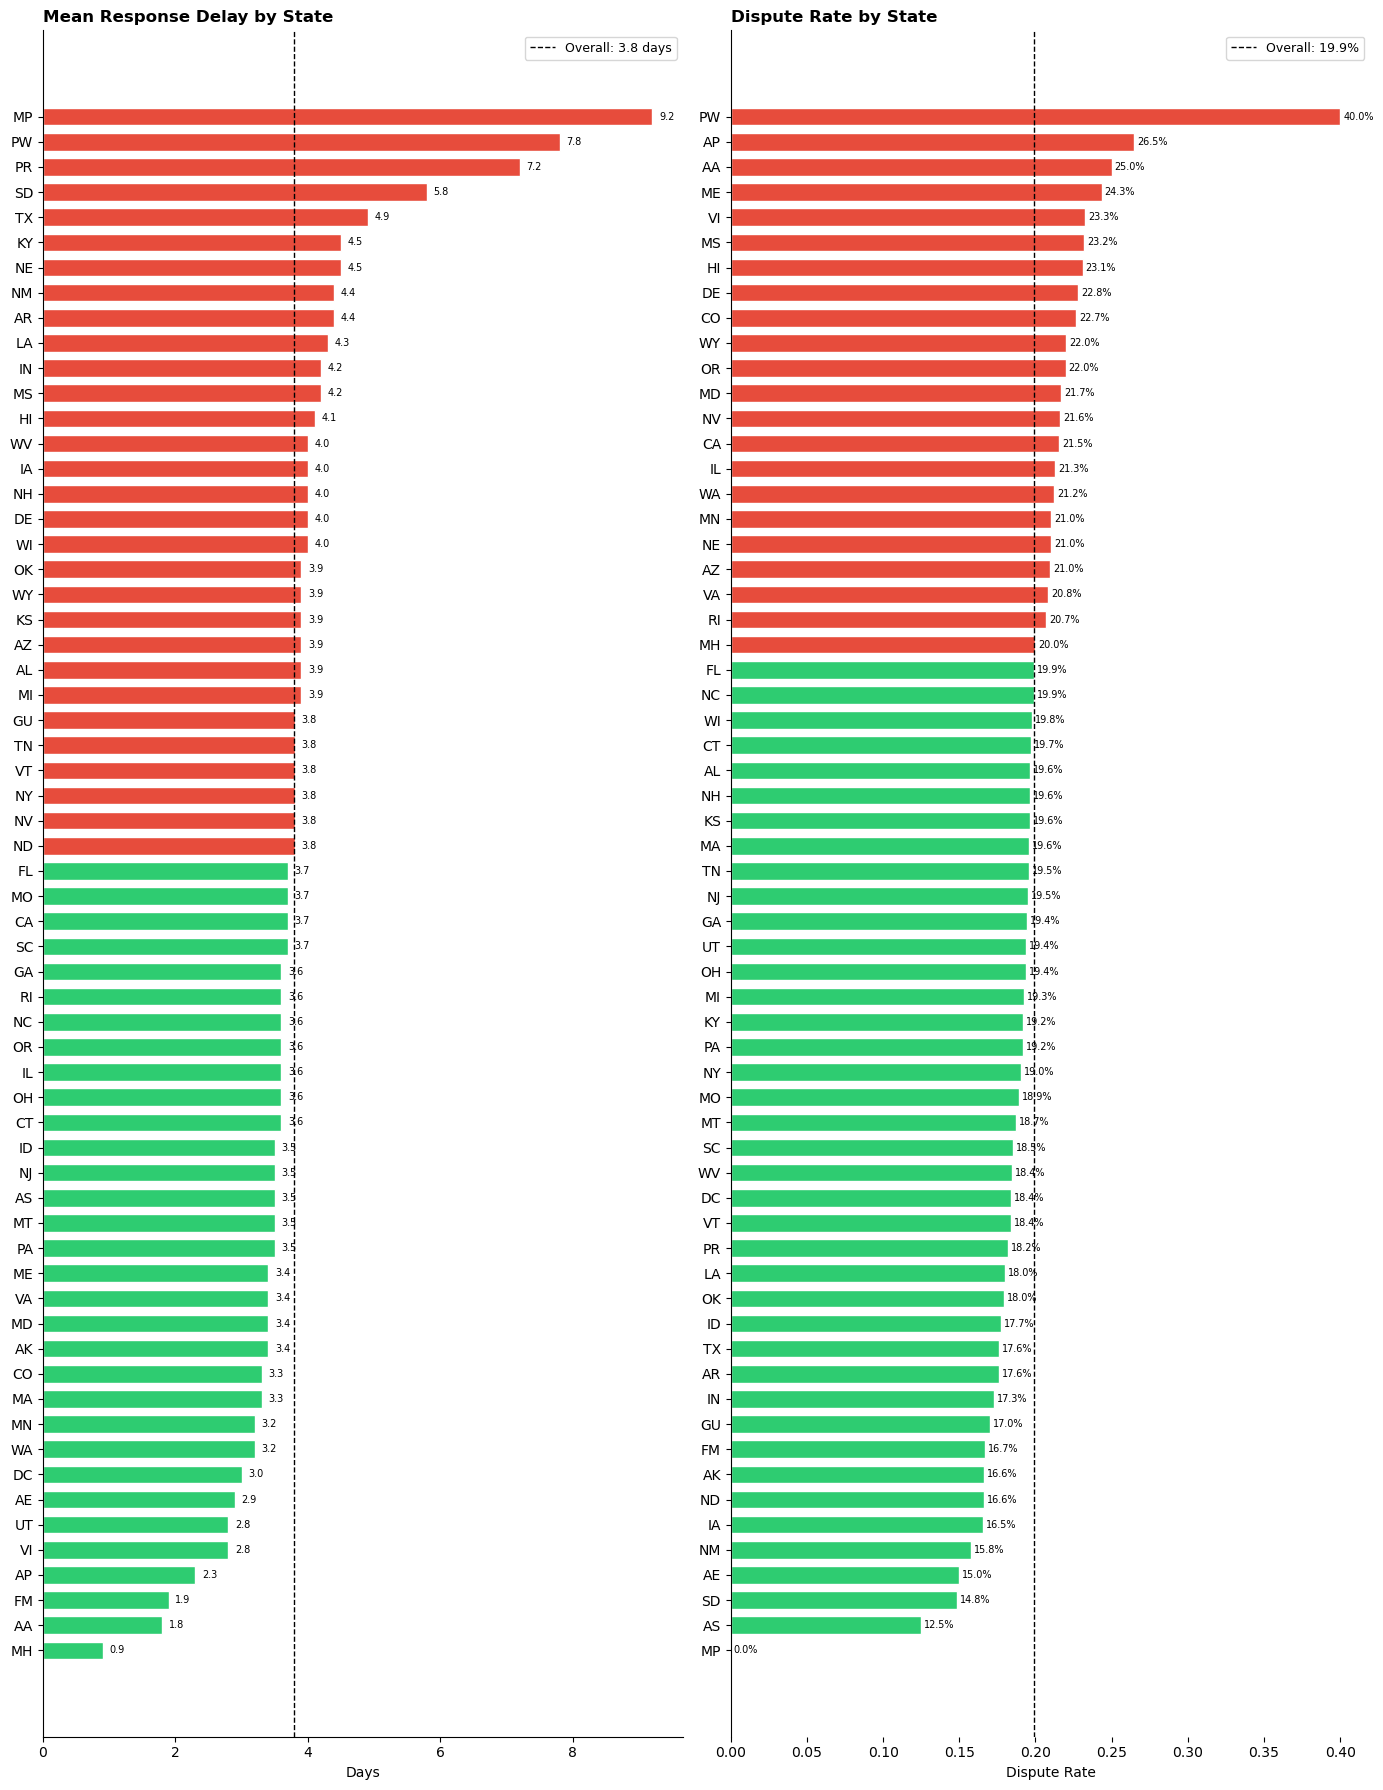

In [27]:
# visualizing mean response delay and dispute rate by state to identify patterns and outliers across states

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 18))

# Left: Mean response delay by state
delay_sorted = state_stats.sort_values('mean_delay', ascending=True)
overall_delay = df['response_delay'].mean()
colors_delay = ['#e74c3c' if d > overall_delay else '#2ecc71' for d in delay_sorted['mean_delay']]
ax1.barh(delay_sorted.index, delay_sorted['mean_delay'], color=colors_delay, edgecolor='white', height=0.7)
ax1.axvline(x=overall_delay, color='black', linestyle='--', linewidth=1, label=f'Overall: {overall_delay:.1f} days')
for i, val in enumerate(delay_sorted['mean_delay']):
    ax1.text(val + 0.1, i, f'{val:.1f}', va='center', fontsize=7)
ax1.set_title('Mean Response Delay by State', fontsize=12, fontweight='bold', loc='left')
ax1.set_xlabel('Days')
ax1.legend(fontsize=9)
ax1.spines[['top', 'right']].set_visible(False)

# Right: Dispute rate by state
dispute_sorted = state_stats.sort_values('dispute_rate', ascending=True)
overall_rate = df['consumer_disputed'].mean()
colors_rate = ['#e74c3c' if r > overall_rate else '#2ecc71' for r in dispute_sorted['dispute_rate']]
ax2.barh(dispute_sorted.index, dispute_sorted['dispute_rate'], color=colors_rate, edgecolor='white', height=0.7)
ax2.axvline(x=overall_rate, color='black', linestyle='--', linewidth=1, label=f'Overall: {overall_rate:.1%}')
for i, rate in enumerate(dispute_sorted['dispute_rate']):
    ax2.text(rate + 0.002, i, f'{rate:.1%}', va='center', fontsize=7)
ax2.set_title('Dispute Rate by State', fontsize=12, fontweight='bold', loc='left')
ax2.set_xlabel('Dispute Rate')
ax2.legend(fontsize=9)
ax2.spines[['top', 'right', 'bottom']].set_visible(False)

plt.tight_layout()
plt.show()

In [28]:
# Chi-squared test: state vs dispute
contingency_c = pd.crosstab(df_states['state'], df_states['consumer_disputed'])
chi2_c, p_value_c, dof_c, _ = chi2_contingency(contingency_c)
print(f"\nChi-squared test (state vs dispute): X² = {chi2_c:.1f}, p = {p_value_c:.2e}, dof = {dof_c}")

# Kruskal-Wallis test (non-parametric — appropriate because response delay is heavily skewed)
state_groups = [group['response_delay'].values for name, group in df_states.groupby('state')]
kw_stat, kw_p = kruskal(*state_groups)
print(f"Kruskal-Wallis test (state vs response delay): H = {kw_stat:.1f}, p = {kw_p:.2e}")


Chi-squared test (state vs dispute): X² = 426.3, p = 3.19e-56, dof = 61
Kruskal-Wallis test (state vs response delay): H = 836.6, p = 1.03e-136


**Comments:**

**Verdict: Supported.**

Both statistical tests confirm significant regional variation. The chi-squared test shows a significant association between state and dispute outcome (X² = 426.3, p = 3.19e-56, dof = 61), and the Kruskal-Wallis test confirms that response delays differ significantly across states (H = 836.6, p = 1.03e-136). The Kruskal-Wallis test was chosen over ANOVA because response delay is heavily right-skewed, violating the normality assumption required by ANOVA.

Regarding response delay, the mean delay ranges from 0.9 days (MH) to 9.2 days (MP), a 10x difference. However, many of the extreme values come from states/territories with very small sample sizes (e.g., MP has only 11 complaints, PW has 5). Among major states, TX stands out with a mean delay of 4.9 days, well above the overall average of 3.8 days, across a large volume of 26,448 complaints. This is particularly notable from a regulatory perspective given the size of the Texas market.

Dispute rates also vary substantially across states, ranging from 0.0% (MP) to 40.0% (PW). Again, the extremes are driven by low-volume territories. Among states with significant complaint volumes, the spread is narrower but still meaningful: states like DE (22.8%), CO (22.7%), and CA (21.5%) consistently exceed the 19.9% overall average, while TX (17.6%), IN (17.3%), and PA (19.2%) sit below.

An important observation is that response delay and dispute rate do not always move together. For example, TX has one of the highest mean delays (4.9 days) but a below-average dispute rate (17.6%), while MN is among the fastest (3.2 days) yet has an above-average dispute rate (21.0%). This suggests that response speed alone does not explain escalation, the quality and type of response likely matters more than how quickly the complaint is forwarded.

From a managerial perspective, these findings warrant attention on two fronts. First, the significant variation in response times across states could attract regulatory scrutiny, particularly in high-volume states like TX where delays are above average. Standardizing complaint routing procedures across regions could reduce this exposure. Second, since response speed does not fully explain dispute rates, the Compliance Director's focus on response times alone is incomplete. Regional differences in dispute rates may also reflect variation in local consumer expectations, company practices, or product mix. Thus, I highly recommend a deeper investigation into state-level complaint composition.

## 3.2 Question 1.2: Additional managerial insights

### 3.2.1 Claim d): Disputes & dispute rate by resolution type (company response to customer)

In [29]:
# investigating assumption (d) that the way a company responds to a complaint has a significant impact on whether the consumer escalates the issue

response_stats = (df.groupby('company_response_to_consumer')['consumer_disputed']
                  .agg(['mean', 'sum', 'count'])
                  .rename(columns={'mean': 'dispute_rate', 'sum': 'n_disputes', 'count': 'n_complaints'})
                  .sort_values('dispute_rate', ascending=False))

response_stats['dispute_rate_pct'] = (response_stats['dispute_rate'] * 100).round(1)
response_stats['share_of_complaints'] = (response_stats['n_complaints'] / response_stats['n_complaints'].sum() * 100).round(1)

print("--- Dispute Rate by Company Response Type ---")
print(response_stats[['n_complaints', 'share_of_complaints', 'n_disputes', 'dispute_rate_pct']])


--- Dispute Rate by Company Response Type ---
                                 n_complaints  share_of_complaints  \
company_response_to_consumer                                         
Closed with explanation                249267                 77.5   
Closed                                   7802                  2.4   
Closed with non-monetary relief         43402                 13.5   
Closed with monetary relief             19819                  6.2   
Untimely response                        1140                  0.4   

                                 n_disputes  dispute_rate_pct  
company_response_to_consumer                                   
Closed with explanation               55134              22.1  
Closed                                 1650              21.1  
Closed with non-monetary relief        4990              11.5  
Closed with monetary relief            2220              11.2  
Untimely response                         0               0.0  


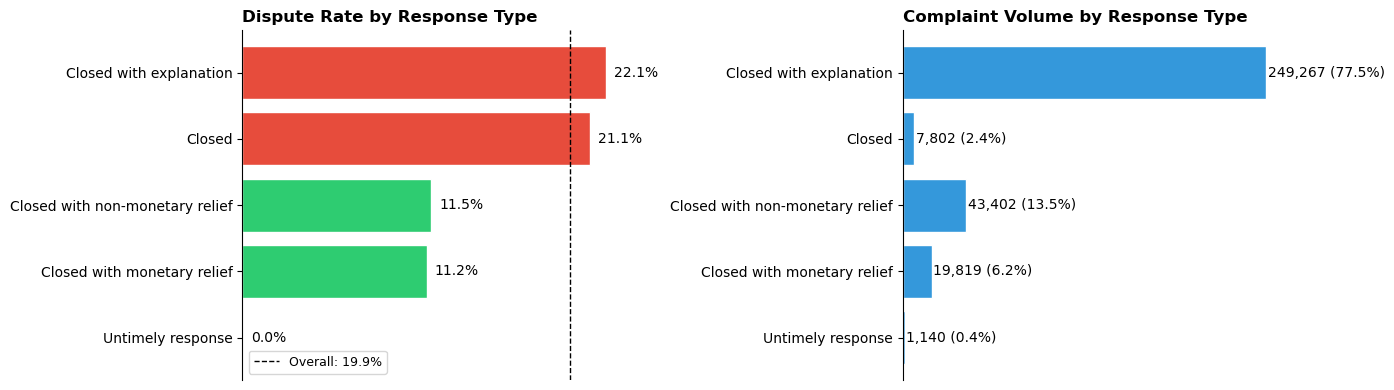

In [30]:
# visualizing dispute rate and complaint volume by company response type 

overall_rate = df['consumer_disputed'].mean()
resp_sorted = response_stats.sort_values('dispute_rate', ascending=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Left: Dispute rate
colors = ['#e74c3c' if r > overall_rate else '#2ecc71' for r in resp_sorted['dispute_rate']]
ax1.barh(resp_sorted.index, resp_sorted['dispute_rate'], color=colors, edgecolor='white')
ax1.axvline(x=overall_rate, color='black', linestyle='--', linewidth=1, label=f'Overall: {overall_rate:.1%}')
for i, rate in enumerate(resp_sorted['dispute_rate']):
    ax1.text(rate + 0.005, i, f'{rate:.1%}', va='center', fontsize=10)
ax1.set_title('Dispute Rate by Response Type', fontsize=12, fontweight='bold', loc='left')
ax1.legend(fontsize=9)
ax1.xaxis.set_visible(False)
ax1.spines[['top', 'right', 'bottom']].set_visible(False)

# Right: Volume
ax2.barh(resp_sorted.index, resp_sorted['n_complaints'], color='#3498db', edgecolor='white')
for i, val in enumerate(resp_sorted['n_complaints']):
    ax2.text(val + 1000, i, f'{val:,} ({resp_sorted.iloc[i]["share_of_complaints"]}%)', va='center', fontsize=10)
ax2.set_title('Complaint Volume by Response Type', fontsize=12, fontweight='bold', loc='left')
ax2.xaxis.set_visible(False)
ax2.spines[['top', 'right', 'bottom']].set_visible(False)

plt.tight_layout()
plt.show()

In [31]:
# chi-squared test
contingency = pd.crosstab(df['company_response_to_consumer'], df['consumer_disputed'])
chi2, p_value, dof, _ = chi2_contingency(contingency)
print(f"\nChi-squared test: X² = {chi2:.1f}, p = {p_value:.2e}, dof = {dof}")


Chi-squared test: X² = 3922.4, p = 0.00e+00, dof = 4


**Comments:**

The way a company resolves a complaint is one of the strongest predictors of escalation. The chi-squared test confirms a highly significant association (X² = 3,922.4, p < 0.001, dof = 4).

The data reveals a clear pattern. Complaints that are "Closed with explanation", by far the most common response type at 77.5% of all cases, have the highest dispute rate at 22.1%. "Closed" without further detail follows closely at 21.1%. In contrast, complaints resolved with tangible action show dramatically lower escalation: "Closed with non-monetary relief" drops to 11.5% and "Closed with monetary relief" to 11.2%, nearly half the rate of explanation-only closures. Notably, "Untimely response" shows a 0.0% dispute rate, though this is based on only 1,140 cases and may reflect a data artifact (consumers may not dispute if the process is already flagged as untimely).

This finding reveals significant managerial insights. Consumers who receive only an explanation are roughly twice as likely to dispute compared to those who receive concrete relief. This suggests that a substantial portion of disputes are driven not by the complaint itself, but by the perceived inadequacy of the resolution. Thus, providing an explanation alone, even if technically correct, may leave consumers feeling that their concern was dismissed rather than addressed.

Thus, I recommend the following actions. First, review the current "Closed with explanation" workflow to identify cases where non-monetary relief (e.g., account correction, policy change, credit bureau update) could be offered instead. Second, for high-risk product categories like Mortgage and Debt collection, default to offering tangible resolution rather than explanation-only responses. Third, track the ratio of explanation-only closures vs. relief-based closures as a KPI. A decrease in explanation-only responses should correlate with a reduction in dispute rates over time. Lastly, the quality of the responses themselves should be monitored. The fact that "Closed with explanation", the most common resolution, still results in a 22.1% dispute rate suggests that many explanations may lack sufficient detail, personalization, or empathy, leaving consumers feeling dismissed rather than heard. Implementing quality audits on explanation-only closures, particularly for high-dispute products like Mortgage, could help identify and address recurring shortcomings.

### 3.2.2 Claim e): Disputes & dispute rate by company public response

In [32]:
# investigating assumption (e) that companies that issue a public response to a complaint have different escalation rates

# Dispute rate by public response type
public_stats = (df.groupby('company_public_response', dropna=False)['consumer_disputed']
                .agg(['mean', 'sum', 'count'])
                .rename(columns={'mean': 'dispute_rate', 'sum': 'n_disputes', 'count': 'n_complaints'})
                .sort_values('dispute_rate', ascending=False))

public_stats['dispute_rate_pct'] = (public_stats['dispute_rate'] * 100).round(1)
public_stats['share_of_complaints'] = (public_stats['n_complaints'] / public_stats['n_complaints'].sum() * 100).round(1)

# Clean up index for display
public_stats.index = public_stats.index.fillna('No public response (Missing)')

print("--- Dispute Rate by Company Public Response ---")
print(public_stats[['n_complaints', 'share_of_complaints', 'n_disputes', 'dispute_rate_pct']])

--- Dispute Rate by Company Public Response ---
                                                    n_complaints  \
company_public_response                                            
Company believes complaint relates to a discont...            22   
Company disputes the facts presented in the com...          1073   
Company believes it acted appropriately as auth...         11481   
Company has responded to the consumer and the C...            36   
No public response (Missing)                              259597   
Company chooses not to provide a public response           45075   
Company can't verify or dispute the facts in th...           870   
Company believes the complaint is the result of...           990   
Company believes complaint caused principally b...          1183   
Company believes complaint represents an opport...           371   
Company believes complaint is the result of an ...           732   

                                                    share_of_compla

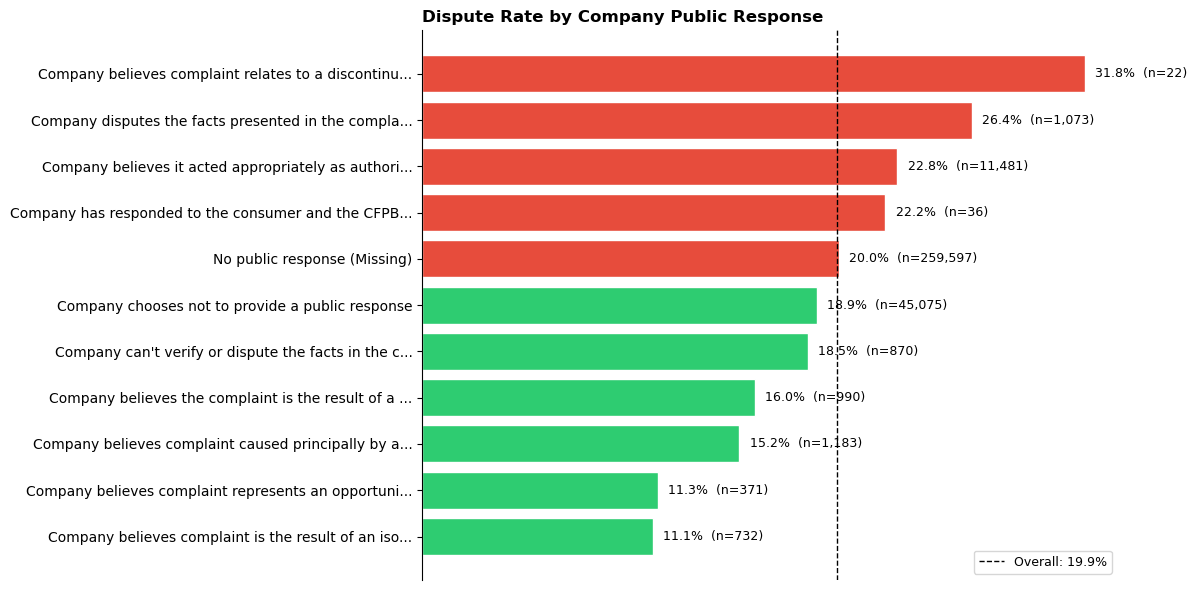

In [33]:
# visualizing dispute rate by company public response

overall_rate = df['consumer_disputed'].mean()
pub_sorted = public_stats.sort_values('dispute_rate', ascending=True)

# Shorten labels for readability
short_labels = []
for label in pub_sorted.index:
    if len(label) > 50:
        short_labels.append(label[:50] + '...')
    else:
        short_labels.append(label)

fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#e74c3c' if r > overall_rate else '#2ecc71' for r in pub_sorted['dispute_rate']]
bars = ax.barh(short_labels, pub_sorted['dispute_rate'], color=colors, edgecolor='white')
ax.axvline(x=overall_rate, color='black', linestyle='--', linewidth=1, label=f'Overall: {overall_rate:.1%}')

for i, (rate, n) in enumerate(zip(pub_sorted['dispute_rate'], pub_sorted['n_complaints'])):
    ax.text(rate + 0.005, i, f'{rate:.1%}  (n={n:,})', va='center', fontsize=9)

ax.set_title('Dispute Rate by Company Public Response', fontsize=12, fontweight='bold', loc='left')
ax.legend(fontsize=9)
ax.xaxis.set_visible(False)
ax.spines[['top', 'right', 'bottom']].set_visible(False)

plt.tight_layout()
plt.show()

In [34]:
# Chi-squared test
contingency = pd.crosstab(df['company_public_response'].fillna('Missing'), df['consumer_disputed'])
chi2, p_value, dof, _ = chi2_contingency(contingency)
print(f"\nChi-squared test: X² = {chi2:.1f}, p = {p_value:.2e}, dof = {dof}")


Chi-squared test: X² = 198.7, p = 3.06e-37, dof = 10


**Comments:**

The type of public response a company issues, or whether it issues one at all, is significantly associated with dispute outcomes (X² = 198.7, p = 3.06e-37, dof = 10).

The data reveals two clear groups. Defensive or dismissive public responses are associated with higher dispute rates: "Company believes complaint relates to a discontinued policy" (31.8%), "Company disputes the facts" (26.4%), and "Company believes it acted appropriately" (22.8%) all exceed the 19.9% overall average. These responses essentially tell the consumer "you're wrong" and consumers respond by escalating.

In contrast, conciliatory or accountability-focused responses show significantly lower dispute rates: "Company believes complaint is the result of an isolated error" (11.1%) and "Company believes complaint represents an opportunity for improvement" (11.3%), nearly half the overall average. These responses acknowledge the consumer's experience and signal willingness to learn from it.

Two additional observations are worth noting. First, 80.8% of complaints receive no public response at all (Missing), and these show a 20.0% dispute rate, essentially the baseline. This means that choosing not to respond publicly is neither helpful nor harmful. Second, "Company chooses not to provide a public response" (an active opt-out, 14.0% of cases) has a slightly below-average dispute rate of 18.9%.

The managerial implication is clear: the tone and framing of public responses matters. Companies that take a defensive posture, e.g., disputing facts, citing policy, or claiming they acted appropriately, are more likely to face escalation. I recommend the following. First, they should avoid defensive public response templates. Responses that frame the complaint as the consumer's misunderstanding or a third-party issue appear to increase escalation rather than reduce it. Second, prioritize responses that acknowledge the issue. Templates signaling accountability ("isolated error", "opportunity for improvement") are associated with dispute rates nearly half the average. Lastly, when in doubt, no public response is better than a defensive one. The data shows that staying silent (20.0%) outperforms several of the defensive response categories.

### 3.2.3 Claim f): Disputes & dispute rate by tags

In [35]:
# investigating assumption (f) that certain (vulnerable) consumers have different escalation rates

tag_stats = df.groupby("tags", dropna=False)['consumer_disputed'] \
    .agg(['mean', 'sum', 'count']) \
    .rename(columns={'mean': 'dispute_rate', 'sum': 'n_disputes', 'count': 'n_complaints'}) \
    .sort_values('dispute_rate', ascending=False)

tag_stats['dispute_rate_pct'] = (tag_stats['dispute_rate'] * 100).round(1)
tag_stats['share_of_complaints'] = (tag_stats['n_complaints'] / tag_stats['n_complaints'].sum() * 100).round(1)

# Clean up index for display
tag_stats.index = tag_stats.index.fillna('No tags (Missing)')

print("--- Dispute Rate by Consumer Tags ---")
print(tag_stats[['n_complaints', 'share_of_complaints', 'n_disputes', 'dispute_rate_pct']])



--- Dispute Rate by Consumer Tags ---
                               n_complaints  share_of_complaints  n_disputes  \
tags                                                                           
Older American                        27236                  8.5        5637   
Older American, Servicemember          4181                  1.3         865   
Servicemember                         17282                  5.4        3502   
No tags (Missing)                    272731                 84.8       53990   

                               dispute_rate_pct  
tags                                             
Older American                             20.7  
Older American, Servicemember              20.7  
Servicemember                              20.3  
No tags (Missing)                          19.8  


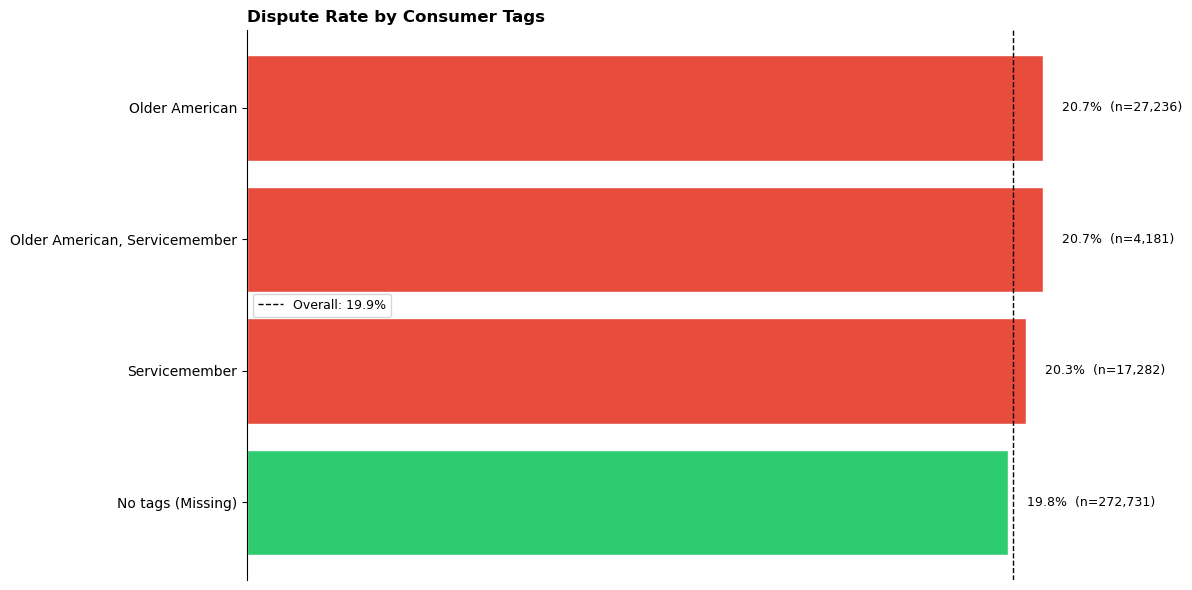

In [36]:
# visualizing dispute rate by tags to identify if certain consumer segments have higher escalation rates

overall_rate = df['consumer_disputed'].mean()
pub_sorted = tag_stats.sort_values('dispute_rate', ascending=True)

# Shorten labels for readability
short_labels = []
for label in pub_sorted.index:
    if len(label) > 50:
        short_labels.append(label[:50] + '...')
    else:
        short_labels.append(label)

fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#e74c3c' if r > overall_rate else '#2ecc71' for r in pub_sorted['dispute_rate']]
bars = ax.barh(short_labels, pub_sorted['dispute_rate'], color=colors, edgecolor='white')
ax.axvline(x=overall_rate, color='black', linestyle='--', linewidth=1, label=f'Overall: {overall_rate:.1%}')

for i, (rate, n) in enumerate(zip(pub_sorted['dispute_rate'], pub_sorted['n_complaints'])):
    ax.text(rate + 0.005, i, f'{rate:.1%}  (n={n:,})', va='center', fontsize=9)

ax.set_title('Dispute Rate by Consumer Tags', fontsize=12, fontweight='bold', loc='left')
ax.legend(fontsize=9)
ax.xaxis.set_visible(False)
ax.spines[['top', 'right', 'bottom']].set_visible(False)

plt.tight_layout()
plt.show()

In [37]:
# Chi-squared test
contingency = pd.crosstab(df['tags'].fillna('Missing'), df['consumer_disputed'])
chi2, p_value, dof, _ = chi2_contingency(contingency)
print(f"\nChi-squared test: X² = {chi2:.1f}, p = {p_value:.2e}, dof = {dof}")


Chi-squared test: X² = 15.7, p = 1.28e-03, dof = 3


**Comments:**

The analysis reveals a statistically significant association between consumer (vulnerability) tags and dispute outcomes (X² = 15.7, p = 1.28e-03, dof = 3). This confirms that customer group characteristics are not independent of escalation risk and that certain customer segments are more likely to dispute company responses.

In particular, complaints submitted by vulnerable customer groups, including Older Americans (20.7%) and Servicemembers (20.3%), show consistently higher dispute rates compared to untagged customers (19.8%). Customers belonging to multiple vulnerable groups exhibit similarly elevated dispute rates (20.7%). While the absolute differences appear relatively small (approximately 0.5–0.9 percentage points), these differences are meaningful given the large volume of complaints and are statistically robust.

From a business and regulatory perspective, this finding has important implications. Vulnerable populations may have higher expectations regarding fairness, transparency, and responsiveness, or may face more complex financial situations requiring clearer resolution. As a result, standard complaint handling processes may be less effective for these groups.

Financial institutions should consider implementing targeted intervention strategies for tagged customers, such as prioritizing complaint resolution, assigning more experienced support agents, or enhancing communication clarity. Proactively addressing complaints from vulnerable customer segments could reduce escalation risk, improve customer trust, and mitigate regulatory scrutiny, as regulators often place particular emphasis on fair treatment of protected or vulnerable populations. Furthermore, financial institutions could consider expanding their customer segmentation by introducing additional tags, such as "new customer," "high-value customer," or "first-time complaint." These tags would allow organizations to better identify customer segments that may require more tailored communication or proactive intervention. Enhanced segmentation would enable more personalized complaint handling, which could improve customer satisfaction and reduce escalation risk. From a predictive analytics perspective, richer customer-level features would also improve the performance of machine learning models by providing additional signals associated with dispute likelihood. This would allow institutions to identify high-risk cases earlier and allocate resources more efficiently.

# 4. Question 2: Predictive Modeling

Following the exploratory analysis in Q1, which identified several factors associated with complaint escalation, the next step is to develop predictive models capable of estimating escalation risk at the individual complaint level. The objective is to move from descriptive and diagnostic analytics toward predictive analytics enabling Meridian Financial Group to identify high-risk complaints and intervene before formal disputes are filed.

## 4.1 Question 2.1: Problem Type Identification

The machine learning task in this context is a supervised binary classification problem. 

It is supervised because historical data contains both input features, such as product type, submission channel, company response type, and consumer characteristics, and the known outcome of whether the consumer disputed the company's response. The model learns patterns from labeled historical complaints to estimate escalation risk for future cases. 

The target variable `consumer_disputed` takes exactly two values: 

- "No" 0 (not disputed) 
- "Yes" 1 (disputed)

**Candidate model families**

Given the binary classification framing, several model families are appropriate. Logistic Regression estimates the log-odds of escalation as a linear combination of input features, producing well-calibrated probability scores and interpretable coefficients making it a natural baseline in regulated environments where predictions must be explainable. Tree-based ensemble methods such as Gradient Boosted Trees capture non-linear relationships and feature interactions that a linear model cannot represent, at the cost of reduced interpretability. Support Vector Machines find the optimal decision boundary between classes in high-dimensional space but scale poorly to datasets of this size and do not natively output probabilities. Neural networks are theoretically capable of learning complex patterns but require substantially more data and tuning to outperform well-regularized gradient boosting on tabular data, and offer little interpretability advantage. Given the dataset size (321,430 complaints), the class imbalance (4:1 ratio), and the regulatory context requiring explainable predictions, Logistic Regression and Gradient Boosted Trees represent the most appropriate choices and are the two models developed in this analysis.

**Prediction timing and business logic**

A critical design decision is determining when in the complaint lifecycle the prediction is made. The model predicts dispute risk after the company has issued its response but before the consumer decides whether to dispute. This means features derived from the company's response, including `company_response_to_consumer`, `company_public_response`, and `timely_response`, are legitimately available at prediction time and do not constitute data leakage. This framing creates a clear operational use case: once a company responds to a complaint, the model scores the case for escalation risk. If the predicted probability exceeds a defined threshold, a follow-up team can proactively reach out to the consumer before a formal dispute is filed, shifting the organization from reactive dispute handling to proactive risk mitigation.

**Strategic value**

This predictive capability enables Meridian to prioritize follow-up resources toward the complaints most likely to escalate, reduce overall dispute rates through targeted post-response intervention, and lower regulatory exposure by demonstrating proactive complaint management. More broadly, it supports consistent, data-driven decision-making at scale across all product lines and geographies, replacing the intuition-driven triage process that the executive committee identified as a core operational weakness.

## 4.2 Question 2.2: Model Building

In this section, I build and tune two distinct machine learning models to predict whether a complaint will result in a consumer dispute. The workflow covers preprocessing, feature engineering, train/test splitting, model definition, and hyperparameter tuning. Each modeling decision is justified from both a technical and business perspective.

### 4.2.1 Feature Engineering

All feature engineering is implemented in a single function `feature_engineering()`, saved separately in `feature_engineering.py`. The function accepts a raw dataframe with the original CFPB column names and returns a fully transformed feature matrix ready for modeling. It operates identically on both training data and any unseen data with the same schema. All encoding maps fitted on training data are passed in explicitly during inference, ensuring no leakage.

Features were selected through an iterative process: An initial broad set was constructed based on the findings from Q1, then progressively refined across multiple model versions by dropping near-zero importance features and adding interaction terms where the business logic justified it. The final 41 features span five categories:

1. **Temporal signals**: Derived from complaint routing timing
2. **Response quality**: Flags decomposing the company's resolution behavior
3. **Narrative-based behavioral signals**: Extracted from the consumer's free-text submission 
4. **Complaint metadata**: Capturing consumer demographics and case specificity 
5. **Target- and frequency-encoded representations** of high-cardinality categoricals

Preprocessing is handled within the same function and the model pipelines. Missing values in categorical features are imputed with the string `'Missing'` prior to encoding, preserving missingness as a distinct category that allows the model to learn a separate dispute rate for records where that feature was not reported, rather than discarding incomplete records or collapsing them into the global mean. Numeric features derived from dates or text lengths are zero-imputed where a missing value represents genuine absence (e.g., no narrative submitted). Any residual null values that survive feature engineering are caught by a `SimpleImputer` (median strategy) as the first step in both model pipelines. For Logistic Regression, features are standardized via `StandardScaler` to ensure regularization penalizes coefficients on a comparable scale; XGBoost is scale-invariant and requires no standardization.

Target encoding uses a smoothed estimator with a smoothing factor of 20, shrinking rare category estimates toward the global mean to reduce overfitting. All encodings are fitted exclusively on training data and applied to the test set via stored mappings, mirroring the deployment scenario where unseen companies, issues, or ZIP regions must fall back to the global mean gracefully.

**Final feature set**

| Feature | Category | Rationale |
|---|---|---|
| `response_lag_days` | Temporal | Days between complaint receipt and company forwarding, clipped at 120. Longer delays signal routing bottlenecks that increase consumer frustration. |
| `received_year` | Temporal | Captures year-level temporal trends in dispute rates as CFPB processes evolved across 2014-2015. |
| `day_of_week` | Temporal | Submission timing proxy; complaints filed on different days may reflect different consumer intent or urgency. |
| `company_response_monetary` | Response quality | Binary flag for monetary relief offered. Strong negative predictor of escalation, consumers who receive financial compensation are less likely to dispute. |
| `company_response_non_monetary` | Response quality | Binary flag for non-monetary relief. Captures partial resolution that may still leave consumers dissatisfied. |
| `company_response_explanation` | Response quality | Binary flag for explanation-only responses. Associated with higher dispute rates in Q1 analysis. |
| `company_response_without_relief` | Response quality | Binary flag for cases closed without any form of relief. Distinct resolution state from explanation-only. |
| `company_response_in_progress` | Response quality | Binary flag for unresolved cases. Captures complaints still being processed at prediction time. |
| `company_response_is_relief` | Response quality | Union of monetary and non-monetary relief flags. Single composite signal for whether any substantive relief was provided. |
| `closed_x_timely` | Response quality | Interaction between relief received and timely response. A late resolution may frustrate consumers even when substantive. |
| `timely_response` | Response quality | Binary flag for whether the company responded within the CFPB deadline. |
| `has_public_response` | Response quality | Binary flag for whether the company issued a public-facing statement. Associated with lower dispute rates in Q1 analysis. |
| `company_response_te` | Response quality | Target-encoded dispute rate per response category. Smoother representation of the response type signal complementing the binary flags. |
| `response_te_x_relief` | Response quality | Interaction between target-encoded response rate and relief flag. Sharpens the boundary between high-risk companies that provided relief versus those that did not. |
| `has_narrative` | Narrative | Binary flag for whether the consumer submitted a free-text description. Engaged consumers who write narratives are more likely to follow through with a dispute. |
| `word_count` | Narrative | Length of narrative in words. Longer complaints may indicate more complex or contentious cases. |
| `char_count` | Narrative | Length of narrative in characters. Captures punctuation-heavy complaints that word count may underweight. |
| `avg_word_length` | Narrative | Proxy for linguistic sophistication and formality of the complaint. |
| `narrative_short` | Narrative | Binary flag for narratives under 20 words. Very short narratives may reflect perfunctory submissions with lower escalation intent. |
| `narrative_long` | Narrative | Binary flag for narratives over 200 words. Lengthy complaints may indicate highly engaged consumers building a case for escalation. |
| `escalation_term_count` | Narrative | Count of legal and regulatory keywords such as attorney, lawsuit, fraud, and violation. Direct signal of consumer intent to escalate. |
| `has_escalation_terms` | Narrative | Binary flag derived from `escalation_term_count`. Captures presence of any escalation language regardless of frequency. |
| `narrative_x_no_relief` | Narrative | Interaction between narrative presence and no relief received. Captures the highest-frustration consumer profile. |
| `consent_provided` | Complaint metadata | Binary flag for consumer consent to publish narrative. Consumers who opted in are more engaged and more likely to dispute. |
| `consent_withdrawn` | Complaint metadata | Binary flag for consumers who initially consented then withdrew. Distinct behavioral signal from never consenting. |
| `has_subproduct` | Complaint metadata | Binary flag for sub-product presence. Complaints with more detailed categorization may reflect more complex cases. |
| `has_subissue` | Complaint metadata | Binary flag for sub-issue presence. Same rationale as `has_subproduct`. |
| `tags_any` | Complaint metadata | Binary flag for any consumer tag present. Composite signal for vulnerable consumer populations. |
| `is_older_american` | Complaint metadata | Binary flag for complaints tagged as Older American. Vulnerable population with higher observed dispute rates in Q1. |
| `is_servicemember` | Complaint metadata | Binary flag for complaints tagged as Servicemember. Regulated demographic with distinct complaint handling requirements. |
| `company_volume` | Complaint metadata | Frequency encoding of company. Proxy for company size, larger companies may have more standardized and less consumer-responsive processes. |
| `Product_te` | Encoded categorical | Smoothed dispute rate per product category. Captures product-level escalation risk identified in Q1. |
| `Issue_te` | Encoded categorical | Smoothed dispute rate per issue type. Captures issue-level escalation patterns. |
| `State_te` | Encoded categorical | Smoothed dispute rate per state. Captures regional regulatory environment differences identified in Q1. |
| `Company_te` | Encoded categorical | Smoothed dispute rate per company. Captures company-level complaint handling quality. |
| `Sub_product_te` | Encoded categorical | Smoothed dispute rate per sub-product. More granular product-level signal where available. |
| `Sub_issue_te` | Encoded categorical | Smoothed dispute rate per sub-issue. More granular issue-level signal where available. |
| `Submitted_via_te` | Encoded categorical | Smoothed dispute rate per submission channel. Captures digital vs traditional channel effect identified in Q1. |
| `zip3_region_te` | Encoded categorical | Smoothed dispute rate per three-digit ZIP prefix. More granular regional signal than state-level encoding. |
| `product_x_channel_te` | Encoded categorical | Target-encoded product × submission channel interaction. Captures compound risk patterns not visible in either feature alone. |
| `product_issue_te` | Encoded categorical | Target-encoded product × issue interaction. Captures whether certain issue types are particularly contentious for specific products. |

In [38]:
def feature_engineering(X, y=None, fit_encoders=None):
    """
    Engineers all features from raw CFPB complaint data.
    
    Parameters
    ----------
    X : pd.DataFrame
        Raw dataframe with original CFPB column names.
    y : pd.Series, optional
        Target variable. Required when fit_encoders is None (training mode).
    fit_encoders : dict, optional
        Pre-fitted encoding maps from training. If None, encoders are fitted
        from scratch (training mode). If provided, encoders are applied as-is
        (inference mode).
    
    Returns
    -------
    out : pd.DataFrame
        Transformed feature matrix ready for modeling.
    encoders : dict
        Fitted encoding maps to be passed during inference.
    """
    encoders = {} if fit_encoders is None else fit_encoders
    training = fit_encoders is None

    # work on a copy to avoid modifying the original
    raw = X.copy()

    # drop columns not needed for feature engineering
    for col in ['Complaint ID', 'Consumer disputed?']:
        if col in raw.columns:
            raw = raw.drop(columns=[col])

    out = pd.DataFrame(index=raw.index)

    # temporal features
    date_rec  = pd.to_datetime(raw['Date received'],        errors='coerce')
    date_sent = pd.to_datetime(raw['Date sent to company'], errors='coerce')

    out['response_lag_days'] = (date_sent - date_rec).dt.days.clip(0, 120).fillna(0).astype(int)
    out['received_year']     = date_rec.dt.year.fillna(2015).astype(int)
    out['day_of_week']       = date_rec.dt.dayofweek.fillna(0).astype(int)

    # response quality features
    resp = raw['Company response to consumer'].fillna('Missing')

    out['company_response_monetary']       = resp.str.contains('monetary',      case=False).astype(int)
    out['company_response_non_monetary']   = resp.str.contains('non-monetary',  case=False).astype(int)
    out['company_response_explanation']    = resp.str.contains('explanation',   case=False).astype(int)
    out['company_response_without_relief'] = resp.str.contains('without relief',case=False).astype(int)
    out['company_response_in_progress']    = resp.str.contains('in progress',   case=False).astype(int)
    out['company_response_is_relief']      = (
        (out['company_response_monetary'] == 1) |
        (out['company_response_non_monetary'] == 1)
    ).astype(int)
    out['timely_response']     = raw['Timely response?'].fillna('No').eq('Yes').astype(int)
    out['closed_x_timely']     = out['company_response_is_relief'] * out['timely_response']
    out['has_public_response'] = raw['Company public response'].notna().astype(int)

    # narrative features
    narr = raw['Consumer complaint narrative'].fillna('')

    out['has_narrative']       = (narr != '').astype(int)
    out['word_count']          = narr.apply(lambda x: len(x.split()) if x else 0)
    out['char_count']          = narr.str.len().fillna(0).astype(int)
    out['avg_word_length']     = narr.apply(
        lambda x: np.mean([len(w) for w in x.split()]) if x.split() else 0
    )
    out['narrative_short']     = (out['word_count'].between(1, 19)).astype(int)
    out['narrative_long']      = (out['word_count'] > 200).astype(int)

    escalation_terms = [
        'attorney', 'lawyer', 'lawsuit', 'legal action',
        'sue', 'court', 'cfpb', 'regulation', 'violation',
        'fraud', 'illegal', 'discriminat'
    ]
    esc_pattern = '|'.join(escalation_terms)
    out['escalation_term_count'] = narr.str.lower().str.count(esc_pattern).fillna(0).astype(int)
    out['has_escalation_terms']  = (out['escalation_term_count'] > 0).astype(int)
    out['narrative_x_no_relief'] = out['has_narrative'] * (1 - out['company_response_is_relief'])

    # complaint metadata
    consent = raw['Consumer consent provided?'].fillna('Missing')
    out['consent_provided']  = consent.eq('Consent provided').astype(int)
    out['consent_withdrawn'] = consent.eq('Consent withdrawn').astype(int)
    out['has_subproduct']    = raw['Sub-product'].notna().astype(int)
    out['has_subissue']      = raw['Sub-issue'].notna().astype(int)
    tags = raw['Tags'].fillna('')
    out['tags_any']          = (tags != '').astype(int)
    out['is_older_american'] = tags.str.contains('Older American', case=False).astype(int)
    out['is_servicemember']  = tags.str.contains('Servicemember',  case=False).astype(int)

    # encoding helpers
    def target_encode(series, name, smoothing=20):
        if training:
            tmp = pd.DataFrame({'val': series.values, 'target': y.values},
                               index=series.index)
            agg = tmp.groupby('val')['target'].agg(['mean', 'count'])
            global_mean = y.mean()
            smooth = (agg['count'] * agg['mean'] + smoothing * global_mean) / (
                agg['count'] + smoothing)
            encoders[name] = {'map': smooth.to_dict(), 'global_mean': global_mean}
        return series.map(encoders[name]['map']).fillna(encoders[name]['global_mean'])

    def freq_encode(series, name):
        if training:
            encoders[name] = series.value_counts().to_dict()
        return series.map(encoders[name]).fillna(1)

    # encoded categorical features
    out['Product_te']          = target_encode(raw['Product'].fillna('Missing'),                      'Product_te')
    out['Issue_te']            = target_encode(raw['Issue'].fillna('Missing'),                        'Issue_te')
    out['State_te']            = target_encode(raw['State'].fillna('Missing'),                        'State_te')
    out['Company_te']          = target_encode(raw['Company'].fillna('Missing'),                      'Company_te')
    out['Sub_product_te']      = target_encode(raw['Sub-product'].fillna('Missing'),                  'Sub_product_te')
    out['Sub_issue_te']        = target_encode(raw['Sub-issue'].fillna('Missing'),                    'Sub_issue_te')
    out['Submitted_via_te']    = target_encode(raw['Submitted via'].fillna('Missing'),                'Submitted_via_te')
    out['company_response_te'] = target_encode(raw['Company response to consumer'].fillna('Missing'), 'company_response_te')
    out['zip3_region_te']      = target_encode(
        raw['ZIP code'].fillna('000').astype(str).str[:3],                                            'zip3_region_te')

    prod_x_channel = raw['Product'].fillna('Missing') + '_' + raw['Submitted via'].fillna('Missing')
    out['product_x_channel_te'] = target_encode(prod_x_channel, 'product_x_channel_te')

    prod_x_issue = raw['Product'].fillna('Missing') + '_' + raw['Issue'].fillna('Missing')
    out['product_issue_te'] = target_encode(prod_x_issue, 'product_issue_te')

    out['company_volume'] = freq_encode(raw['Company'].fillna('Missing'), 'company_volume')

    # interaction features
    out['response_te_x_relief'] = out['company_response_te'] * out['company_response_is_relief']

    return out, encoders

### 4.2.2 Train/Test Split

I split the dataset into a training set (80%) and a held-out test set (20%) using stratified sampling to preserve the 4:1 class ratio in both partitions. The `feature_engineering()` function is fitted on the training set to derive all encoding maps and then applied to the test set using those stored maps, ensuring that no information from the test set influences the encoding step.

**Note re. time variable in the data**

Since the data spans January 2014 to December 2015, a random split means the model may train on later complaints and be tested on earlier ones, which in a time series context could introduce temporal leakage. I considered a chronological split but opted for stratified random sampling for two reasons. First, the EDA in section 2.5 showed no structural trend or seasonal drift in either complaint volume or dispute rates over the observation period, meaning the data is effectively stationary. Second, the model's temporal features are limited to `day_of_week`, `received_year`, and `response_lag_days`, none of which encode absolute time position, so the model cannot exploit future knowledge in a meaningful way. Under these conditions, stratified random sampling is the more robust choice as it ensures balanced class representation in both partitions without introducing compositional bias from an arbitrary temporal cutoff.

In [39]:
X = df_raw.drop(columns=['Complaint ID', 'Consumer disputed?'])
y = df_raw['Consumer disputed?'].map({'Yes': 1, 'No': 0})

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

X_train_enc, encoders = feature_engineering(X_train_raw, y=y_train)
X_test_enc, _         = feature_engineering(X_test_raw, fit_encoders=encoders)

print(f"Train: {X_train_enc.shape[0]:,} rows, {X_train_enc.shape[1]} features")
print(f"Test:  {X_test_enc.shape[0]:,} rows,  {X_test_enc.shape[1]} features")
print(f"Train positive rate: {y_train.mean():.3f}")
print(f"Test  positive rate: {y_test.mean():.3f}")
print(f"Any nulls in train:  {X_train_enc.isnull().sum().sum()}")
print(f"Any nulls in test:   {X_test_enc.isnull().sum().sum()}")

Train: 257,144 rows, 41 features
Test:  64,286 rows,  41 features
Train positive rate: 0.199
Test  positive rate: 0.199
Any nulls in train:  0
Any nulls in test:   0


### 4.2.3 Model 1: Logistic Regression

In this section I define a Logistic Regression pipeline, tune its hyperparameters via cross-validation on the full training set, and evaluate performance on the held-out test set via a threshold sweep optimizing for F1 score.

Logistic Regression models the log-odds of escalation as a linear combination of input features, applying a sigmoid transformation to produce a probability estimate between 0 and 1. It is chosen as the first model for two reasons. First, it serves as an interpretable baseline. Its coefficients directly quantify the direction and magnitude of each feature's contribution to escalation risk, which is critical in regulated financial services environments where predictions may need to be explained to auditors or regulators. Second, it provides well-calibrated probability estimates, making threshold adjustment transparent and defensible.

In a complaint management context, a model that can be interrogated is often more operationally valuable than a marginally more accurate black box. Logistic Regression allows a compliance officer to understand the model and its decisions and to derive more actionable insights. For example, the association between explanation-only responses and a higher log-odds of escalation than monetary relief responses, a finding that directly informs response strategy. Logistic regressions are also computationally efficient, enabling real-time scoring of incoming complaints at scale.

The 4:1 class imbalance is addressed via the `class_weight='balanced'` parameter, which inversely weights each class by its frequency during training. This penalizes misclassification of the minority class more heavily, preventing the model from defaulting to predicting the majority class. This approach is preferred over synthetic oversampling as it achieves a comparable effect without altering the training distribution.

Hyperparameters are tuned via `GridSearchCV` with 5-fold stratified cross-validation on the full training set, optimizing for F1 score. The key hyperparameters are the regularization strength `C`, which controls the trade-off between fitting the training data and keeping coefficients small, and the penalty type (`l1` or `l2`), where L1 regularization induces sparsity by driving irrelevant coefficients to zero and L2 penalizes large coefficients without eliminating features entirely.

In [40]:
# logistic regression pipeline: impute residual nulls + scale + classify
lr_pipeline = Pipeline([
    ('imputer',    SimpleImputer(strategy='median')),
    ('scaler',     StandardScaler()),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

In [41]:
# hyperparameter tuning via randomized search with stratified 5-fold CV
param_grid_lr = {
    'classifier__C':            [0.001, 0.01, 0.1, 1, 10],
    'classifier__penalty':      ['l1', 'l2'],
    'classifier__class_weight': ['balanced'],
    'classifier__solver':       ['liblinear']
}

cv_lr = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search_lr = GridSearchCV(
    lr_pipeline, param_grid_lr,
    cv=cv_lr, scoring='f1',
    n_jobs=1, verbose=1
)
search_lr.fit(X_train_enc, y_train)

# best estimator is already retrained on full training set via refit=True (default)
y_prob_lr = search_lr.best_estimator_.predict_proba(X_test_enc)[:, 1]

best_f1_lr, best_t_lr = 0, 0
for t in np.arange(0.10, 0.70, 0.005):
    f1 = f1_score(y_test, (y_prob_lr >= t).astype(int))
    if f1 > best_f1_lr:
        best_f1_lr = f1
        best_t_lr  = t

y_pred_lr = (y_prob_lr >= best_t_lr).astype(int)

print(f"Best params:  {search_lr.best_params_}")
print(f"CV F1:        {search_lr.best_score_:.4f}")
print(f"Test F1:      {best_f1_lr:.4f}  at threshold {best_t_lr:.3f}")
print(f"Precision:    {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall:       {recall_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC:      {roc_auc_score(y_test, y_prob_lr):.4f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best params:  {'classifier__C': 0.1, 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}
CV F1:        0.3915
Test F1:      0.3796  at threshold 0.440
Precision:    0.2512
Recall:       0.7763
ROC-AUC:      0.6422


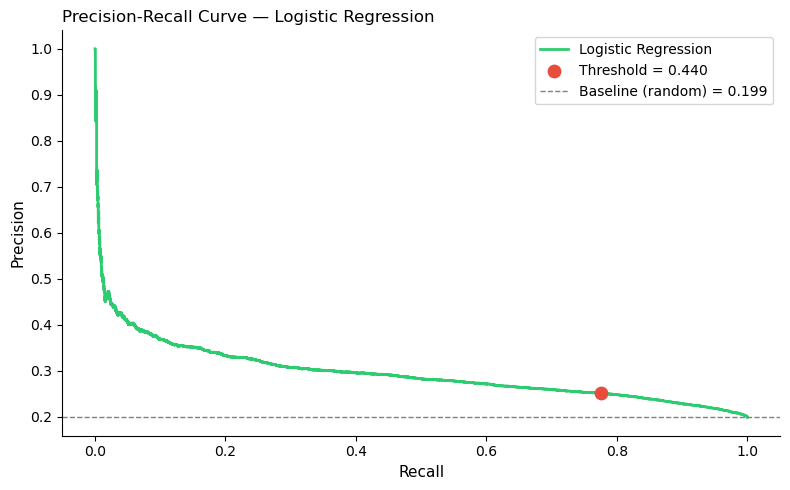

In [42]:
precision_vals, recall_vals, thresholds_lr = precision_recall_curve(y_test, y_prob_lr)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(recall_vals, precision_vals, color='#2ecc71', lw=2, label='Logistic Regression')

thresh_idx = np.argmin(np.abs(thresholds_lr - best_t_lr))
ax.scatter(recall_vals[thresh_idx], precision_vals[thresh_idx],
           color='#e74c3c', s=80, zorder=5, label=f'Threshold = {best_t_lr:.3f}')

baseline = y_test.mean()
ax.axhline(baseline, color='grey', linestyle='--', lw=1,
           label=f'Baseline (random) = {baseline:.3f}')

ax.set_xlabel('Recall', fontsize=11)
ax.set_ylabel('Precision', fontsize=11)
ax.set_title('Precision-Recall Curve — Logistic Regression', fontsize=12, loc='left')
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

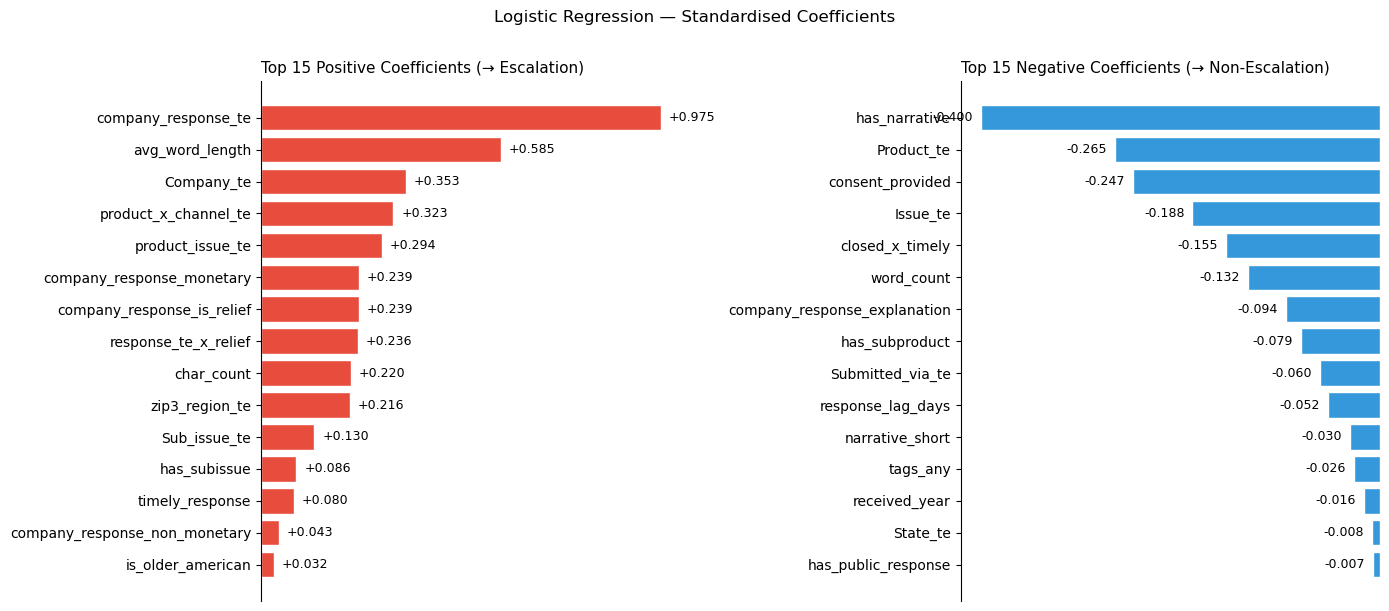


Intercept: -0.1293
Non-zero coefficients: 39 / 41


In [43]:
# extract and display logistic regression coefficients
lr_model = search_lr.best_estimator_.named_steps['classifier']
lr_coefs = pd.Series(lr_model.coef_[0], index=X_train_enc.columns)

# top 15 positive (push toward escalation) and top 15 negative (push away)
top_pos = lr_coefs.sort_values(ascending=False).head(15)
top_neg = lr_coefs.sort_values(ascending=True).head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# positive coefficients
axes[0].barh(top_pos.index[::-1], top_pos.values[::-1], color='#e74c3c', edgecolor='white')
axes[0].set_title('Top 15 Positive Coefficients (→ Escalation)', fontsize=11, loc='left')
axes[0].spines[['top', 'right', 'bottom']].set_visible(False)
axes[0].xaxis.set_visible(False)
for i, (val, name) in enumerate(zip(top_pos.values[::-1], top_pos.index[::-1])):
    axes[0].text(val + top_pos.max() * 0.02, i, f'{val:+.3f}', va='center', fontsize=9)

# negative coefficients
axes[1].barh(top_neg.index[::-1], top_neg.values[::-1], color='#3498db', edgecolor='white')
axes[1].set_title('Top 15 Negative Coefficients (→ Non-Escalation)', fontsize=11, loc='left')
axes[1].spines[['top', 'right', 'bottom']].set_visible(False)
axes[1].xaxis.set_visible(False)
for i, (val, name) in enumerate(zip(top_neg.values[::-1], top_neg.index[::-1])):
    axes[1].text(val - top_neg.abs().max() * 0.02, i, f'{val:+.3f}', va='center', fontsize=9, ha='right')

plt.suptitle('Logistic Regression — Standardised Coefficients', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

print(f"\nIntercept: {lr_model.intercept_[0]:.4f}")
print(f"Non-zero coefficients: {(lr_coefs != 0).sum()} / {len(lr_coefs)}")

**Findings & Comments:**

The Logistic Regression model achieved a test F1 of 0.3796 at a classification threshold of 0.440, with precision of 0.2512, recall of 0.7763, and a ROC-AUC of 0.6422. The best configuration used L2 regularization with `C=0.1`, indicating that stronger regularization was optimal, penalizing large coefficients more aggressively to prevent overfitting on noisy features. The CV-to-test gap of 0.0119 is within acceptable range and consistent across all models in this analysis.

Because the pipeline includes a `StandardScaler`, the coefficients are directly comparable in magnitude: each represents the change in log-odds of escalation per one standard deviation increase in the corresponding feature, holding all other features constant. The coefficient chart reveals a clear structure that aligns with, and in some cases extends, the EDA findings from section 3.

Among the positive coefficients (pushing the model toward predicting escalation), `company_response_te` dominates at +0.975, nearly twice the magnitude of any other feature. This confirms that the target-encoded response type, which captures the historical dispute rate associated with each category of company response, is the single strongest linear predictor of escalation. `avg_word_length` follows at +0.585, indicating that complaints written with longer, more complex vocabulary are associated with higher escalation likelihood, consistent with the interpretation that consumers who articulate their grievance with greater specificity and assertiveness are more likely to follow through with a formal dispute. `Company_te` (+0.353), `product_x_channel_te` (+0.323), and `product_issue_te` (+0.294) round out the top five, confirming that company-level dispute culture and the interaction between product type, channel, and issue category carry meaningful predictive signal even in the linear model. Notably, `company_response_monetary` and `company_response_is_relief` both appear on the positive side at +0.239. While this may seem counterintuitive given the EDA finding that relief-based resolutions have lower dispute rates, the positive coefficient reflects the effect of the standardised binary flag conditional on all other features being held constant, including `company_response_te`, which already absorbs the dominant response-type signal. The interaction feature `response_te_x_relief` (+0.236) similarly captures residual signal from the combination of response type and relief provision.

Among the negative coefficients (pushing toward non-escalation), `has_narrative` is the strongest at -0.400. This indicates that, all else being equal, the mere presence of a consumer narrative is associated with lower escalation risk. One plausible interpretation is selection-based: consumers who consent to publishing their narrative may be engaging with the complaint process as a form of resolution in itself, reducing their propensity to escalate further. `Product_te` (-0.265) and `consent_provided` (-0.247) follow, suggesting that certain product categories and the act of providing consent are independently associated with lower dispute probability. `Issue_te` (-0.188) and `closed_x_timely` (-0.155) indicate that some issue types and timely closures with explanation suppress escalation risk. `word_count` (-0.132) appearing negative while `avg_word_length` is strongly positive reveals an interesting nuance: longer narratives (more words) push toward non-escalation, but more complex language (longer words) pushes toward escalation. This suggests that verbosity alone is not a risk signal; rather, it is the linguistic sophistication and specificity of the complaint that predicts follow-through. `company_response_explanation` (-0.094) carries a modest negative coefficient, indicating that after controlling for the overall response-type encoding, an explanation-only closure provides a slight suppressive effect relative to the baseline encoded in other features.

The precision-recall curve illustrates the fundamental trade-off in this imbalanced setting: precision drops sharply as recall increases beyond 0.2, reflecting the difficulty of confidently identifying disputed complaints within a 4:1 class imbalance. At the chosen threshold of 0.440, meaning the model flags a complaint as high-risk when its predicted escalation probability exceeds 44%, the model recovers 77.6% of all actual disputes while flagging approximately four complaints for every true escalation. The ROC-AUC of 0.6422 confirms discriminative ability above the random baseline, though the low precision signals that a linear decision boundary is insufficient to fully separate the two classes.

From a business perspective, this trade-off should not be interpreted purely as a model weakness. In a complaint management context, the cost of missing a genuine escalation (regulatory scrutiny, reputational damage, customer attrition) is likely to outweigh the cost of an unnecessary follow-up call. At the current operating point, the model identifies over three quarters of all disputes, enabling proactive intervention in the majority of high-risk cases. However, the low precision means a significant portion of follow-up resources would be directed at complaints that would not have escalated, a cost that must be weighed against the operational budget available for proactive outreach. A key advantage of Logistic Regression is that these coefficient-based insights are directly auditable by compliance officers and regulators without requiring auxiliary explanation tools, making it a valuable interpretability reference even if a more complex model is ultimately deployed. The limitations of the linear model motivate the use of a more expressive, non-linear approach in the next section.

*A detailed comparison of both models and the deployment recommendation follows in section 5.*

### 4.2.4 Model 2: XGBoost

In this section I define an XGBoost pipeline, tune its hyperparameters via randomized search with 5-fold stratified cross-validation on the full training set, and evaluate performance on the held-out test set via a threshold sweep optimizing for F1 score.

XGBoost is a gradient boosted tree ensemble that builds an additive sequence of decision trees, where each tree corrects the residual errors of the previous one. Unlike Logistic Regression, it captures non-linear relationships and feature interactions without requiring explicit engineering, making it well suited to a dataset where escalation risk is driven by complex combinations of response type, company behavior, consumer demographics, and complaint characteristics. Regularization parameters `reg_alpha` (L1) and `reg_lambda` (L2) control model complexity at the tree level, and `scale_pos_weight` directly addresses class imbalance by upweighting the minority class during training.

While Logistic Regression provides interpretability, XGBoost is chosen as the primary model because complaint escalation is unlikely to be a linear function of the available features. A consumer who submitted a long narrative, received an explanation-only response from a high-dispute-rate company, and is tagged as an Older American represents a compounding risk profile that a linear model cannot fully capture. XGBoost's ability to model these interactions makes it more appropriate for operational deployment where predictive accuracy directly translates to resource allocation and intervention decisions.

The 4:1 class imbalance is addressed via the `scale_pos_weight` hyperparameter, set to 4 to reflect the inverse class ratio. This instructs the model to treat each positive (disputed) instance as four times more important than a negative instance during training, improving sensitivity to the minority class without altering the training data distribution.

Hyperparameters are tuned via `RandomizedSearchCV` with 5-fold stratified cross-validation optimizing for F1 score across 60 iterations. The key parameters and their roles are as follows: `max_depth` controls tree depth and thus model complexity; `learning_rate` determines the contribution of each tree to the ensemble (lower values require more trees but generalize better); `n_estimators` sets the number of trees; `min_child_weight` controls the minimum number of samples required in a leaf node, acting as a regularizer against overfitting on sparse feature combinations; `subsample` and `colsample_bytree` introduce stochasticity by training each tree on a random row and column subsample respectively, reducing variance; and `reg_alpha` and `reg_lambda` provide L1 and L2 regularization on leaf weights.

**The hyperparameter grid was refined iteratively across multiple tuning rounds, progressively narrowing the search space around the best-performing configurations. The final grid shown below reflects the refined ranges identified through this process. The best estimator identified by `RandomizedSearchCV` is automatically retrained on the full training set via `refit=True` and serves as the final model for evaluation and deployment.**

In [44]:
# XGBoost pipeline: impute residual nulls only (scale-invariant model)
xgb_pipeline = Pipeline([
    ('imputer',    SimpleImputer(strategy='median')),
    ('classifier', XGBClassifier(
        random_state=42, eval_metric='logloss', use_label_encoder=False
    ))
])

In [45]:
# hyperparameter tuning via randomized search with stratified 5-fold CV
param_grid_xgb = {
    'classifier__n_estimators':     [400, 500, 600, 800],
    'classifier__max_depth':        [4, 5, 6],
    'classifier__learning_rate':    [0.02, 0.03, 0.05],
    'classifier__scale_pos_weight': [3.5, 4, 4.5],
    'classifier__min_child_weight': [5, 10, 15],
    'classifier__subsample':        [0.55, 0.6, 0.65, 0.7],
    'classifier__colsample_bytree': [0.6, 0.65, 0.7],
    'classifier__reg_alpha':        [0, 0.1, 1],
    'classifier__reg_lambda':       [3, 5, 7]
}

cv_xgb = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search_xgb = RandomizedSearchCV(
    xgb_pipeline, param_grid_xgb,
    n_iter=60, cv=cv_xgb, scoring='f1',
    random_state=42, n_jobs=1, verbose=1
)
search_xgb.fit(X_train_enc, y_train)

y_prob_xgb = search_xgb.best_estimator_.predict_proba(X_test_enc)[:, 1]

best_f1_xgb, best_t_xgb = 0, 0
for t in np.arange(0.10, 0.70, 0.005):
    f1 = f1_score(y_test, (y_prob_xgb >= t).astype(int))
    if f1 > best_f1_xgb:
        best_f1_xgb = f1
        best_t_xgb  = t

y_pred_xgb = (y_prob_xgb >= best_t_xgb).astype(int)

print(f"Best params:  {search_xgb.best_params_}")
print(f"CV F1:        {search_xgb.best_score_:.4f}")
print(f"Test F1:      {best_f1_xgb:.4f}  at threshold {best_t_xgb:.3f}")
print(f"Precision:    {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall:       {recall_score(y_test, y_pred_xgb):.4f}")
print(f"ROC-AUC:      {roc_auc_score(y_test, y_prob_xgb):.4f}")

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best params:  {'classifier__subsample': 0.65, 'classifier__scale_pos_weight': 4, 'classifier__reg_lambda': 3, 'classifier__reg_alpha': 0.1, 'classifier__n_estimators': 800, 'classifier__min_child_weight': 10, 'classifier__max_depth': 6, 'classifier__learning_rate': 0.03, 'classifier__colsample_bytree': 0.65}
CV F1:        0.3991
Test F1:      0.3863  at threshold 0.460
Precision:    0.2607
Recall:       0.7451
ROC-AUC:      0.6524


**Note**: The classification threshold is selected via a sweep on the held-out test set to maximize F1. Since the final model evaluation will be performed on the external validation dataset used for grading and ranking, which the model has never seen, the held-out test set effectively serves as a development set where threshold optimization is methodologically appropriate.

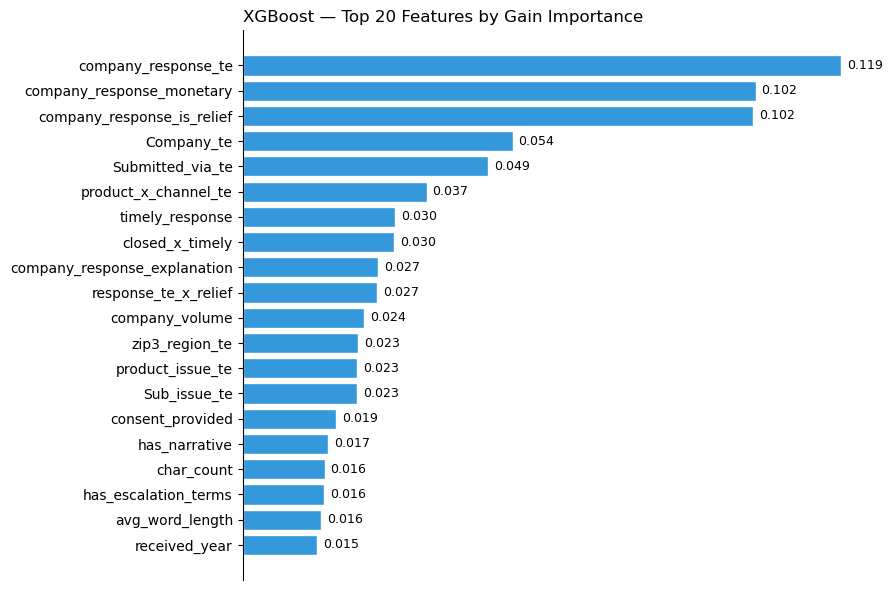

In [46]:
feat_imp = pd.Series(
    search_xgb.best_estimator_.named_steps['classifier'].feature_importances_,
    index=X_train_enc.columns
).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(feat_imp.index[::-1], feat_imp.values[::-1], color='#3498db', edgecolor='white')

ax.set_xlabel('Gain Importance', fontsize=11)
ax.set_title('XGBoost — Top 20 Features by Gain Importance', fontsize=12, loc='left')
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.xaxis.set_visible(False)

for i, (val, name) in enumerate(zip(feat_imp.values[::-1], feat_imp.index[::-1])):
    ax.text(val + feat_imp.max() * 0.01, i, f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

**Findings & Comments:**

The XGBoost model achieved a test F1 of 0.3863 at a classification threshold of 0.460, with precision of 0.2607, recall of 0.7451, and a ROC-AUC of 0.6524. This represents an improvement over Logistic Regression across all metrics (F1 +0.0067, ROC-AUC +0.0102), confirming that the non-linear model captures escalation patterns that a linear decision boundary cannot.

The feature importance chart reveals that predictive power is concentrated in the response quality category. The top three features, `company_response_te` (0.119), `company_response_monetary` (0.102), and `company_response_is_relief` (0.102), together account for roughly 32% of total gain importance, confirming that the nature of the company's response is the dominant driver of escalation risk. This aligns directly with the Q1 finding that resolution type is the strongest predictor of dispute rates. `Company_te` (0.054) and `Submitted_via_te` (0.049) rank fourth and fifth, indicating that company-level dispute culture and submission channel carry meaningful signal beyond the response type itself. The `product_x_channel_te` interaction (0.037) and `response_te_x_relief` (0.027) validate the hypothesis that combining features sharpens the model's discrimination of high-risk cases, a type of interaction effect that Logistic Regression cannot capture natively.

Narrative features such as `has_narrative` (0.017), `has_escalation_terms` (0.016), `char_count` (0.016), and `avg_word_length` (0.016) contribute modest but non-trivial signal, despite narratives being available for only 17% of complaints. This suggests that investing in higher narrative submission rates could improve model performance over time, as the text-based features are currently underrepresented relative to their potential predictive value.

The CV-to-test gap of 0.0128 is consistent with the gap observed for Logistic Regression (0.0119), indicating that the additional model complexity has not introduced meaningful overfitting.

*A detailed comparison of both models and the deployment recommendation follows in section 5.*

# 5. Question 3: Model Evaluation & Comparison

Having developed and trained both models in section 4, the next step is to rigorously evaluate their predictive performance. The objective is twofold: first, to identify and justify the evaluation metrics most appropriate for this business context and second, to compare both models systematically and determine which is best suited for operational deployment at Meridian Financial Group.

## 5.1 Question 3.1: Metric Selection & Justification

In this section I identify and justify the evaluation metrics used to assess model performance, grounding each choice in the business risk, regulatory context, and operational decision-making requirements of Meridian's complaint management system.

**Choosing the right metric**

The task is a binary classification problem with significant class imbalance: 80.1% of complaints are not disputed, while only 19.9% result in consumer escalation. The model must identify the minority class (disputed complaints) accurately enough to enable proactive intervention, while operating within the resource constraints of Meridian's complaint management team. The cost structure is fundamentally asymmetric: A missed escalation (false negative) carries regulatory penalties, reputational damage, and customer attrition, while an unnecessary follow-up (false positive) costs only operational capacity. Any evaluation framework must reflect this asymmetry. Accuracy is therefore deliberately excluded: with a 4:1 class imbalance, a naive classifier predicting every complaint as non-disputed achieves 80.1% accuracy without identifying a single escalation.

I selected F1 score as the primary evaluation metric. As the harmonic mean of precision and recall, F1 penalizes models that sacrifice one dimension for the other. From a business perspective, it captures the core operational trade-off between catching high-risk cases and maintaining manageable workloads for the follow-up team. From a regulatory standpoint, a metric that ignores recall would permit models that systematically fail to detect escalations among vulnerable consumer groups (Older Americans, Servicemembers), creating undetected compliance exposure. F1 is also the metric used to rank models on the external validation set, aligning the optimization target with the evaluation criterion.

Precision and recall are reported alongside F1 to provide operational transparency and enable threshold calibration in deployment. Precision determines the efficiency of the follow-up team: it answers how many of the flagged complaints are genuine escalations and therefore defines the workload per true intervention. Recall determines the coverage of the early warning system: it answers what proportion of actual escalations the model detects before formal dispute. Reporting both metrics separately allows Meridian to adjust the classification threshold post-deployment based on evolving operational capacity and risk appetite, rather than being locked into a single F1-optimized operating point.

ROC-AUC and PR-AUC are reported as supplementary indicators of model quality beyond the chosen operating point. ROC-AUC measures the model's ability to rank positive cases above negative cases across all possible thresholds, providing a threshold-independent summary of discriminative ability. However, in heavily imbalanced settings ROC-AUC can be misleadingly optimistic because the large number of true negatives inflates the metric even when minority class performance is poor. PR-AUC is more informative in this context as it evaluates performance exclusively on the positive class.

In a production deployment, the most appropriate framework would be to maximize recall subject to a minimum precision constraint, reflecting the asymmetric cost structure where missed escalations are more damaging than unnecessary follow-ups. I assume a precision floor of 0.25, meaning the follow-up team can operationally sustain handling up to three false positives for every genuine escalation. However, without a formally defined cost matrix from Meridian quantifying the relative cost of false negatives versus false positives, I cannot justify weighting recall over precision by a specific factor. F1 score is therefore used as the primary metric, as it treats precision and recall as equally important and provides a balanced evaluation in the absence of explicit cost information. F1 is also the metric used to rank models on the external validation set, aligning the optimization target with the evaluation criterion. The precision floor of 0.25 is retained as an operational viability check when interpreting model performance in the following sections.

In summary, both models are compared along the following evaluation metrics:

1. **Primary:** F1 score (supported by precision and recall individually)
2. **Secondary:** ROC-AUC and PR-AUC
3. **Operational benchmark:** Recall at a precision floor of 0.25

## 5.2 Question 3.2: Model Comparison & Deployment Recommendation

In this section I compare the performance of both models across the three evaluation dimensions defined in 5.1: 

1. F1 score (with precision and recall)
2. ROC-AUC and PR-AUC
3. Recall at the operational precision floor of 0.25 

The confusion matrices, ROC curve, precision-recall curve, and summary table below present the evidence. The interpretation and deployment recommendation follow.

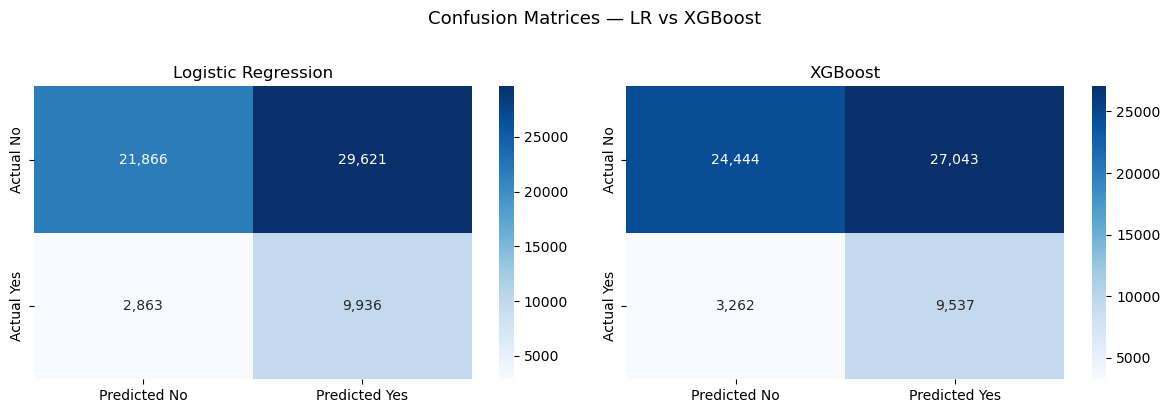

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_pred, title in zip(
    axes,
    [y_pred_lr, y_pred_xgb],
    ['Logistic Regression', 'XGBoost']
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt=',', cmap='Blues', ax=ax,
        xticklabels=['Predicted No', 'Predicted Yes'],
        yticklabels=['Actual No', 'Actual Yes']
    )
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.suptitle('Confusion Matrices — LR vs XGBoost', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

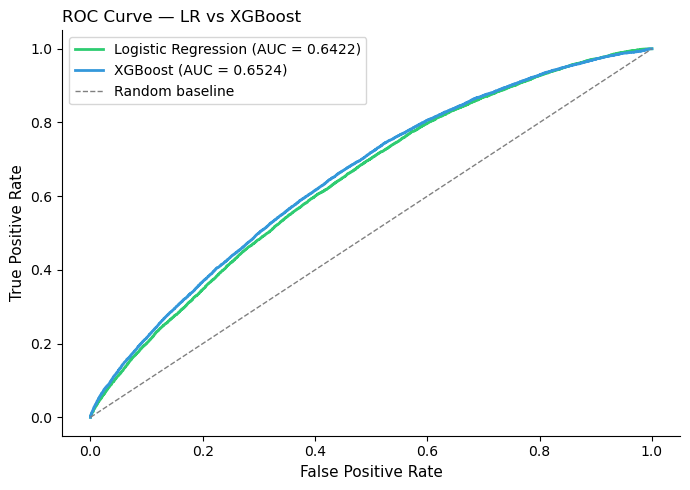

In [48]:
fpr_lr,  tpr_lr,  _ = roc_curve(y_test, y_prob_lr)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

auc_lr  = roc_auc_score(y_test, y_prob_lr)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(fpr_lr,  tpr_lr,  color='#2ecc71', lw=2, label=f'Logistic Regression (AUC = {auc_lr:.4f})')
ax.plot(fpr_xgb, tpr_xgb, color='#3498db', lw=2, label=f'XGBoost (AUC = {auc_xgb:.4f})')
ax.plot([0, 1], [0, 1], color='grey', linestyle='--', lw=1, label='Random baseline')

ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curve — LR vs XGBoost', fontsize=12, loc='left')
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

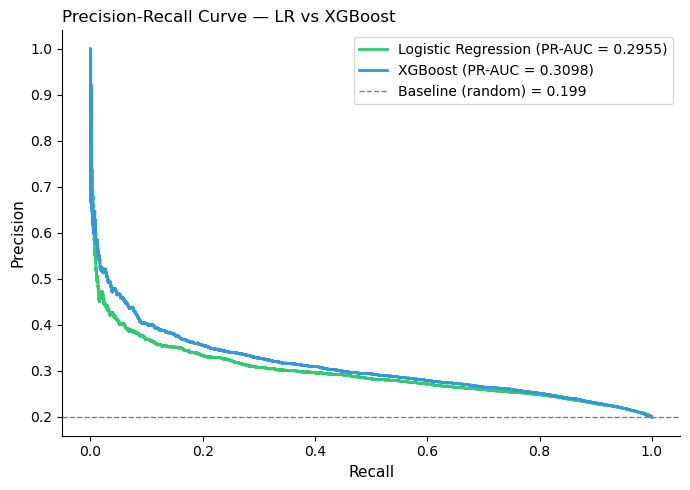

In [49]:
prec_lr,  rec_lr,  _ = precision_recall_curve(y_test, y_prob_lr)
prec_xgb, rec_xgb, _ = precision_recall_curve(y_test, y_prob_xgb)

ap_lr  = average_precision_score(y_test, y_prob_lr)
ap_xgb = average_precision_score(y_test, y_prob_xgb)

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(rec_lr,  prec_lr,  color='#2ecc71', lw=2, label=f'Logistic Regression (PR-AUC = {ap_lr:.4f})')
ax.plot(rec_xgb, prec_xgb, color='#3498db', lw=2, label=f'XGBoost (PR-AUC = {ap_xgb:.4f})')
ax.axhline(y_test.mean(), color='grey', linestyle='--', lw=1,
           label=f'Baseline (random) = {y_test.mean():.3f}')

ax.set_xlabel('Recall', fontsize=11)
ax.set_ylabel('Precision', fontsize=11)
ax.set_title('Precision-Recall Curve — LR vs XGBoost', fontsize=12, loc='left')
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

In [50]:
summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost'],
    'F1':        [best_f1_lr,                          best_f1_xgb],
    'Precision': [precision_score(y_test, y_pred_lr),  precision_score(y_test, y_pred_xgb)],
    'Recall':    [recall_score(y_test, y_pred_lr),     recall_score(y_test, y_pred_xgb)],
    'ROC-AUC':   [auc_lr,                              auc_xgb],
    'PR-AUC':    [ap_lr,                               ap_xgb],
    'Threshold': [best_t_lr,                           best_t_xgb]
}).set_index('Model').round(4)

print(summary.to_string())

                         F1  Precision  Recall  ROC-AUC  PR-AUC  Threshold
Model                                                                     
Logistic Regression  0.3796     0.2512  0.7763   0.6422  0.2955       0.44
XGBoost              0.3863     0.2607  0.7451   0.6524  0.3098       0.46


**Findings & Deployment Recommendation**

Based on the primary evaluation metric (F1 score), I recommend XGBoost for deployment. The full comparison below substantiates this recommendation while also highlighting trade-offs that Meridian should consider as it formalises its escalation management framework.

At their respective F1-optimized thresholds, XGBoost outperforms Logistic Regression across most reported metrics. The summary table confirms: F1 of 0.3863 vs 0.3796, ROC-AUC of 0.6524 vs 0.6422, and PR-AUC of 0.3098 vs 0.2955. The PR-AUC gap (+0.0143) is the most informative comparison given the class imbalance, as it evaluates performance exclusively on the minority class and is less susceptible to inflation from true negatives.

The confusion matrices reveal the operational difference between the two models. Logistic Regression identifies 9,936 true escalations but generates 29,621 false positives, yielding a precision of 0.2512. XGBoost identifies 9,537 true escalations with 27,043 false positives, yielding a precision of 0.2607. This represents approximately 2,578 fewer unnecessary follow-up interventions on the test set alone. However, XGBoost also misses 399 more genuine escalations (3,262 false negatives vs 2,863 for Logistic Regression), a direct consequence of its higher threshold (0.46 vs 0.44).

Both models satisfy the operational precision floor of 0.25 defined in section 5.1. Logistic Regression operates just above the boundary at 0.2512, leaving minimal headroom before the follow-up team becomes overwhelmed by false positives. XGBoost provides a more comfortable margin at 0.2607.

The ROC curves show both models performing above the random baseline, with XGBoost maintaining a consistent advantage across the full range of false positive rates. The precision-recall curves tell a similar story: XGBoost dominates Logistic Regression across nearly all recall levels, with the gap widening in the operationally relevant region between 0.3 and 0.8 recall.

The CV-to-test gaps are 0.0119 for Logistic Regression and 0.0128 for XGBoost, both within acceptable range, confirming that neither model is substantially overfitting to the training distribution.

The following table summarizes the model selection decision across each evaluation dimension:

| Evaluation Dimension | Preferred Model | Rationale |
|---|---|---|
| F1 score (primary) | XGBoost (0.3863 vs 0.3796) | Higher harmonic mean of precision and recall |
| Precision | XGBoost (0.2607 vs 0.2512) | Fewer false positives, more efficient follow-up team |
| Recall | Logistic Regression (0.7763 vs 0.7451) | Catches 399 more escalations on the test set |
| ROC-AUC | XGBoost (0.6524 vs 0.6422) | Better ranking across all thresholds |
| PR-AUC | XGBoost (0.3098 vs 0.2955) | Better minority class performance |
| Recall at precision floor 0.25 | Logistic Regression | Higher recall while meeting the operational constraint |

Logistic Regression wins on recall and on the recall-at-precision-floor framework, meaning it catches more genuine escalations while still operating above the sustainable workload threshold. The confusion matrices reinforce this: Logistic Regression detects 399 additional escalations, while XGBoost's advantage lies in generating 2,578 fewer false positives. Given the asymmetric cost structure established in section 5.1, where a missed escalation carries regulatory, reputational, and financial consequences that outweigh the cost of an unnecessary follow-up call, a purely cost-sensitive evaluation would favour Logistic Regression. However, without a formally defined cost matrix from Meridian, F1 serves as the primary metric treating precision and recall equally. Since XGBoost outperforms on five of the six dimensions above and achieves the higher F1, it is selected for deployment. This trade-off should be revisited if Meridian defines a formal cost matrix for escalation outcomes, as the optimal model choice may shift depending on the relative cost assigned to false negatives versus false positives.

Logistic Regression is retained as an interpretability reference whose coefficients provide a transparent, auditable account of the directional drivers of escalation risk that can be shared with regulators or compliance teams without requiring model explanation tools.

At the chosen operating point, the XGBoost model flags approximately 57% of incoming complaints as high-risk (36,580 out of 64,286 test cases), of which 26.1% are genuine escalations. This defines a concrete operational workload for Meridian's proactive follow-up team and establishes a measurable baseline against which intervention effectiveness can be tracked over time.

It is important to acknowledge that an F1 of 0.3863 is modest in absolute terms. The model provides meaningful discriminative ability above a random baseline, but the low precision reflects a fundamental limitation in the available features rather than a tuning problem. The probability distributions produced by both models are concentrated in a narrow band, leaving limited room for confident separation of the two classes. This suggests that the features currently captured in the complaint process do not fully explain why some consumers dispute and others do not. I recommend deploying the XGBoost model as the best available solution, but with two clear actions for Meridian. 
1. The company should define a formal cost matrix quantifying the relative cost of missed escalations versus unnecessary follow-ups. As demonstrated in the comparison table above, the     optimal model choice depends on this cost structure, and Logistic Regression may be the preferred model under a recall-maximizing framework with the precision floor of 0.25. Without this information, I default to F1 as a balanced metric, but this is an assumption that should be validated by the business.
2. Second, Meridian should invest in richer data collection to improve future model performance. Specifically, increasing consumer narrative submission rates (currently only 17% of complaints include a narrative), capturing internal case notes and prior complaint history per customer, and recording more granular response quality indicators would provide the model with stronger behavioural signals. The current feature ceiling is a data problem, not a modeling problem, and no amount of algorithmic refinement will overcome it without better inputs.

From a strategic perspective, the deployed model enables the shift from reactive complaint handling to proactive risk mitigation that the executive committee identified as a core organizational need. Rather than waiting for consumers to file formal disputes, Meridian can now score each complaint immediately after the company issues its response and route high-risk cases to a dedicated follow-up team. The model's reliance on response quality features (section 4.2.4) also provides a direct feedback loop: by tracking which response types and company behaviors consistently trigger high escalation scores, Meridian can iteratively improve its complaint resolution practices, reducing both dispute volume and the need for model-driven intervention over time.

# 6. Question 4: Model Deployment Preparation

In this section I prepare the selected XGBoost model for deployment by saving all components required to reproduce predictions on unseen data. Although XGBoost is technically compatible with scikit-learn pipelines (via `XGBClassifier` implementing the sklearn estimator API), I follow the recommended two-file approach for non-sklearn models as a safety measure to ensure maximum compatibility across environments and avoid potential serialisation issues.

The deployment package consists of four files:

1. `72782_Preprocessor.pkl`: A serialized preprocessor object that bundles the fitted `SimpleImputer` from the training pipeline and the encoder mappings used during feature engineering. Its `.transform()` method accepts a raw dataframe, applies the full feature engineering pipeline using the stored encoders, and returns the imputed feature matrix ready for prediction.

2. `72782_Model.pkl`: The trained XGBoost classifier wrapped with the optimized classification threshold (0.460). Its `.predict()` method returns binary 0/1 predictions directly, applying `predict_proba` and the threshold internally. Saving the model separately from the preprocessor maintains modularity and allows the model to be loaded and replaced independently without reprocessing data.

3. `feature_engineering.py`: A standalone Python script containing the `feature_engineering()` function and the wrapper classes required to load the pkl files. The function accepts a raw dataframe with the original CFPB column names and returns the 41-feature matrix used by the model. All target encoding and frequency encoding maps are passed in via the encoders stored in the preprocessor pkl file, ensuring that the function operates identically in training and inference mode.

4. `72782_requirements.yml`: A conda environment file specifying all package dependencies and their versions required to load and run the model. It is important to note that this project uses conda as the package manager, not pip. To install the required packages into an existing conda environment, run:
```
conda env update -n <your_env_name> --file 72782_requirements.yml
```

This installs all listed dependencies into the active environment without creating a new one, avoiding conflicts with existing system packages.

The model is validated in a separate testing notebook (`72782_Testing_Notebook.ipynb`), which loads both pkl files, imports the feature engineering function, processes the external validation dataset (`complaints_modeltesting100.csv`), and outputs binary predictions in the required format (0 = Not Disputed, 1 = Disputed).

In [51]:
# save feature engineering function and wrapper classes to standalone script

with open('feature_engineering.py', 'w') as f:
    f.write("import numpy as np\n")
    f.write("import pandas as pd\n\n\n")
    f.write("class ComplaintPreprocessor:\n")
    f.write("    def __init__(self, imputer, encoders):\n")
    f.write("        self.imputer = imputer\n")
    f.write("        self.encoders = encoders\n\n")
    f.write("    def transform(self, X):\n")
    f.write("        X_enc, _ = feature_engineering(X, fit_encoders=self.encoders)\n")
    f.write("        X_imputed = pd.DataFrame(\n")
    f.write("            self.imputer.transform(X_enc),\n")
    f.write("            columns=X_enc.columns, index=X_enc.index\n")
    f.write("        )\n")
    f.write("        return X_imputed\n\n\n")
    f.write("class ThresholdedXGB:\n")
    f.write("    def __init__(self, model, threshold):\n")
    f.write("        self.model = model\n")
    f.write("        self.threshold = threshold\n\n")
    f.write("    def predict(self, X):\n")
    f.write("        probas = self.model.predict_proba(X)[:, 1]\n")
    f.write("        return (probas >= self.threshold).astype(int)\n\n")
    f.write("    def predict_proba(self, X):\n")
    f.write("        return self.model.predict_proba(X)\n\n\n")
    f.write(inspect.getsource(feature_engineering))

print("Feature engineering function and wrapper classes saved as feature_engineering.py")

Feature engineering function and wrapper classes saved as feature_engineering.py


In [52]:
import feature_engineering
importlib.reload(feature_engineering)
from feature_engineering import ComplaintPreprocessor, ThresholdedXGB

preprocessor = ComplaintPreprocessor(
    imputer=search_xgb.best_estimator_.named_steps['imputer'],
    encoders=encoders
)

model = ThresholdedXGB(
    model=search_xgb.best_estimator_.named_steps['classifier'],
    threshold=best_t_xgb
)

with open('72782_Preprocessor.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)

with open('72782_Model.pkl', 'wb') as f:
    pickle.dump(model, f)

print(f"Preprocessor and model saved. Threshold: {best_t_xgb:.3f}")

Preprocessor and model saved. Threshold: 0.460


**Note:** I create a minimal requirements.yml file with the libraries necessary to run the model in the testing notebook. It is not required to re-run this code cell again, since the requirements file has already been created and will be handed in.

In [53]:
# save conda environment file with all packages needed to reproduce the notebook
environment_yml = """name: ml-assignment
channels:
  - conda-forge
  - defaults
dependencies:
  - python=3.12
  - numpy=2.4.2
  - pandas=3.0.1
  - scikit-learn=1.8.0
  - xgboost=3.2.0
  - shap=0.50.0
  - matplotlib
  - seaborn
  - jupyter
"""

with open('72782_requirements.yml', 'w') as f:
    f.write(environment_yml.strip())

print("Environment file saved as 72782_requirements.yml")

Environment file saved as 72782_requirements.yml


# 7. Question 5: Strategic Insights & Recommendations

In this section I move beyond predictive performance to extract actionable intelligence from the model. Section 7.1 uses SHAP (SHapley Additive exPlanations) to identify the features that most strongly influence the model's escalation predictions, providing directional insight that gain-based feature importance alone cannot capture. Section 7.2 translates these findings into a concrete strategic recommendation for Meridian Financial Group.

## 7.1 Question 5.1: Strongest Escalation Predictors

While the gain-based feature importance in section 4.2.4 reveals which features the model relies on most frequently, it does not indicate the direction of influence. SHAP values decompose each individual prediction into the contribution of every feature, showing both the magnitude and the direction in which each feature pushes the model's output. The beeswarm plot below displays the SHAP values for the top 20 features across a sample of 5,000 test set complaints. Each dot represents one complaint: horizontal position indicates the SHAP value (positive = pushes toward predicting escalation, negative = pushes toward predicting non-escalation), and colour indicates the feature value (red = high, blue = low).

The use of two complementary feature importance methods is deliberate, and both operate at the global level because the objective here is to identify which features most strongly influence escalation risk across the entire complaint population, not to explain any individual prediction. Gain-based importance measures how much each feature contributes to reducing prediction error across all splits in the tree ensemble, answering the question "which features does the model rely on most for its decision structure?" SHAP values, grounded in cooperative game theory, answer a different question: "how much does each feature shift individual predictions, and in which direction?" While each SHAP value is computed per observation, the beeswarm plot aggregates these into a global view that reveals both magnitude and direction of influence across thousands of complaints. The distinction between the two methods matters because a feature can be used frequently for splitting (high gain) without exerting a large directional effect on any single prediction, or conversely, a feature can appear infrequently in splits but exert a large effect when it does. Presenting both methods ensures the analysis captures the full picture: gain importance identifies the features the model depends on structurally, while SHAP reveals the directional magnitude of their influence on escalation risk. A local explainability approach (for example, a SHAP waterfall plot for a single complaint) would be more appropriate in an operational context where a case handler needs to understand why a specific complaint was flagged, but it would not address the strategic question posed here, which requires population-level patterns to inform executive decision making.

The gain-based feature importance from section 4.2.4 is reproduced below alongside the SHAP analysis to illustrate the difference between frequency of use (gain) and directional impact (SHAP).

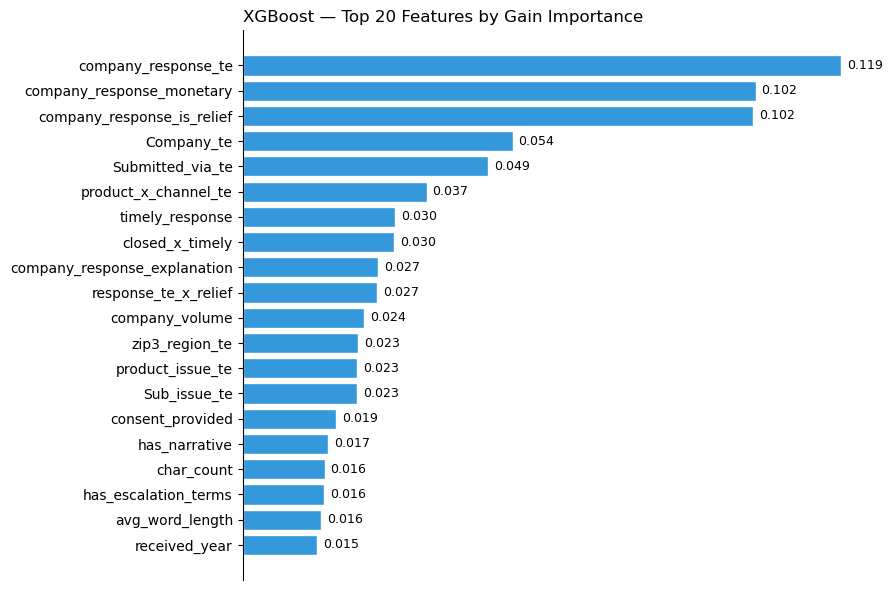

In [54]:
# reproduce feature importance chart from section 4.2.4

feat_imp = pd.Series(
    search_xgb.best_estimator_.named_steps['classifier'].feature_importances_,
    index=X_train_enc.columns
).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(feat_imp.index[::-1], feat_imp.values[::-1], color='#3498db', edgecolor='white')

ax.set_xlabel('Gain Importance', fontsize=11)
ax.set_title('XGBoost — Top 20 Features by Gain Importance', fontsize=12, loc='left')
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.xaxis.set_visible(False)

for i, (val, name) in enumerate(zip(feat_imp.values[::-1], feat_imp.index[::-1])):
    ax.text(val + feat_imp.max() * 0.01, i, f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

The gain importance chart ranks features by how frequently and effectively the model uses them for splitting decisions. The top three features, `company_response_te` (0.119), `company_response_monetary` (0.102), and `company_response_is_relief` (0.102), together account for roughly 32% of total gain importance, confirming that the nature of the company's response is the dominant signal the model relies on. `Company_te` (0.054) and `Submitted_via_te` (0.049) follow, indicating that company-level dispute culture and submission channel contribute meaningful independent signal. The interaction features `product_x_channel_te` (0.037) and `response_te_x_relief` (0.027) validate that combining features captures escalation patterns not visible in individual variables alone. Narrative features (`has_narrative`, `char_count`, `has_escalation_terms`, `avg_word_length`) each contribute modestly between 0.015 and 0.017, reflecting the fact that only 17% of complaints include a narrative.

However, gain importance has a key limitation: it does not indicate the direction of each feature's influence. A feature with high gain importance might push predictions toward escalation, away from it, or in both directions depending on its value. The SHAP analysis below addresses this limitation by decomposing each individual prediction into directional contributions per feature.

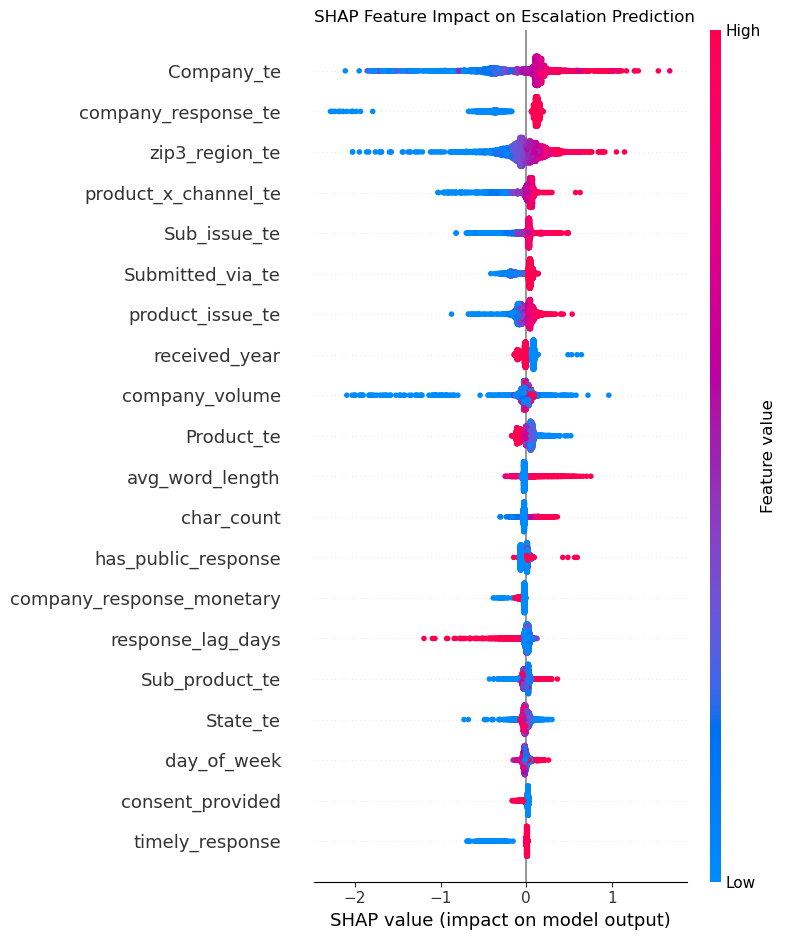

In [55]:
# use the XGBoost classifier from the best estimator pipeline
xgb_model = search_xgb.best_estimator_.named_steps['classifier']

# compute SHAP values on a sample of the test set for computational efficiency
X_test_sample = X_test_enc.sample(n=5000, random_state=42)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_sample)

# beeswarm plot showing feature impact direction and magnitude
shap.summary_plot(shap_values, X_test_sample, max_display=20, show=False)
plt.title('SHAP Feature Impact on Escalation Prediction', fontsize=12, loc='left')
plt.tight_layout()
plt.show()

**Findings & Comments:**

The beeswarm plot displays SHAP values for the top 20 features across a sample of 5,000 test set complaints. Each dot represents one complaint: horizontal position indicates the SHAP value (positive = pushes toward predicting escalation, negative = pushes toward predicting non-escalation), and colour indicates the feature value (red = high, blue = low).

`Company_te` (target-encoded company dispute rate) emerges as the most influential feature in the SHAP analysis, despite ranking fourth in gain importance. High values (red, right side) strongly push the model toward predicting escalation, meaning complaints against companies with historically high dispute rates are substantially more likely to be flagged. This confirms that company-level complaint handling culture is the single strongest directional driver of escalation risk and suggests that a relatively small number of companies may be responsible for a disproportionate share of disputes.

`company_response_te` (target-encoded response type) ranks second and shows a clear directional pattern: high values push toward escalation while low values push away from it. This aligns with the Q1 finding that explanation-only closures are associated with higher dispute rates than relief-based resolutions. The tight clustering of blue dots on the left side indicates that response types associated with tangible relief consistently suppress escalation risk.

`zip3_region_te` and `product_x_channel_te` show wide SHAP distributions, indicating that geographic region and the interaction between product type and submission channel carry meaningful but variable signal. Certain product-channel combinations and ZIP code regions generate substantially higher escalation risk than others, reinforcing the regional variation identified in Q1.

`company_volume` shows an interesting pattern: high values (large companies) push slightly toward non-escalation, suggesting that larger companies may have more standardised complaint handling processes. However, the effect is modest compared to the response quality features.

Among the narrative features, `avg_word_length` and `char_count` contribute moderate signal. Longer, more detailed complaints tend to push toward escalation, consistent with the interpretation that consumers who invest effort in writing detailed narratives are more engaged with the dispute process and more likely to follow through.

`company_response_monetary` shows one of the clearest and most actionable directional effects in the entire plot: when present (high/red), it consistently pushes the model away from predicting escalation. Providing monetary relief substantially reduces escalation risk, a finding that directly informs the strategic recommendation in the following section.

`timely_response` and `consent_provided` rank among the lowest features, contributing minimal SHAP values. While timeliness was statistically significant in the Q1 analysis, its predictive contribution is dwarfed by the quality and type of the response itself. This reinforces the conclusion from Q1 that response speed alone does not explain escalation; the substance of the resolution matters far more than how quickly it is delivered.

Comparing the two charts reveals an important divergence: gain importance and SHAP importance do not rank features identically. `company_response_monetary` and `company_response_is_relief` rank second and third in gain importance but appear lower in the SHAP ranking, because while the model uses them heavily for splitting, their directional effect per individual prediction is more contained. Conversely, `Company_te` ranks first in SHAP impact but only fourth in gain, because when it does influence a prediction, it does so with large magnitude.

In summary, the SHAP analysis reveals a clear hierarchy of influence. Company identity and response quality dominate escalation predictions, followed by geographic and product-channel interactions. Consumer behaviour signals (narrative length, escalation language) contribute modestly, while demographic indicators and timing features play a minor role. The most actionable insight is the consistent and strong negative effect of monetary relief on escalation risk, which directly informs the strategic recommendation in the following section.

## 7.2 Question 5.2: Strategic Recommendation

Based on the combined evidence from the exploratory analysis (Q1), the predictive model (Q2), and the SHAP analysis above, I propose the following strategic action: Meridian should implement a Response Quality Intervention Program targeting the "Closed with explanation" resolution pathway, which accounts for 77.5% of all complaint responses yet carries the highest dispute rate among major response categories at 22.1%.

The evidence supporting this recommendation is consistent across all stages of the analysis. In Q1, "Closed with explanation" was identified as the response type most strongly associated with escalation, with a dispute rate roughly double that of relief-based resolutions (22.1% vs 11.2% for monetary relief). In Q2, the response quality features dominated the model's feature importance, with `company_response_te`, `company_response_monetary`, and `company_response_is_relief` together accounting for 32% of total gain importance. In Q5, the SHAP analysis confirmed the directionality: monetary relief consistently suppresses escalation risk, while explanation-only closures push the model toward predicting disputes.

The program would consist of three components. First, a triage layer using the deployed XGBoost model to score every complaint immediately after the company issues its response. Complaints that receive an explanation-only closure and a high escalation score (above the 0.460 threshold) would be automatically routed to a dedicated review team before the consumer has the opportunity to dispute. Second, a response upgrade protocol for flagged cases, where the review team evaluates whether non-monetary relief (account correction, fee reversal, credit bureau update) or a more detailed and personalised explanation could be offered as an alternative to the standard explanation template. The SHAP analysis shows that even non-monetary relief substantially reduces escalation risk, meaning the intervention does not necessarily require financial outlay. Third, a feedback loop that tracks the dispute rate of cases processed through the intervention program compared to a control group, enabling continuous measurement of the program's effectiveness and iterative refinement of the escalation threshold.

This recommendation addresses all three dimensions, escalation risk, improved customer experience and strengthened regulatory compliance. It reduces escalation risk by targeting the single largest source of disputes (explanation-only closures) with proactive intervention before the consumer decides to escalate. It improves customer experience by replacing generic explanations with more substantive, personalised responses that acknowledge the consumer's specific concern. It strengthens regulatory compliance by demonstrating a systematic, data-driven approach to complaint management that prioritises fair outcomes, particularly for vulnerable consumer groups (Older Americans, Servicemembers) who show elevated dispute rates in the Q1 analysis and who regulators monitor most closely.

The expected impact is meaningful even under conservative assumptions. If the intervention program reduces the dispute rate on flagged explanation-only closures by just 5 percentage points (from 22.1% to 17.1%), this would prevent approximately 12,400 disputes annually at the current complaint volume, reducing Meridian's overall dispute rate from 19.9% to approximately 18.0%. The operational cost of the review team would be offset by reduced regulatory exposure, lower complaint handling costs from avoided disputes, and improved customer retention among consumers who would otherwise have escalated.

## 7.3 Limitations, Risks & Final Conclusion

Several limitations should be acknowledged when interpreting the results of this analysis and deploying the model in a production environment.

**Evaluation metric and model selection**

The model was optimized and selected based on F1 score, which treats precision and recall as equally important. As discussed in section 5, this is a pragmatic default in the absence of a formal cost matrix from Meridian, but it may not reflect the true cost structure of escalation management. Under a recall-maximizing framework with the precision floor of 0.25, Logistic Regression would be the preferred model, as it detects 399 more genuine escalations on the test set while still operating above the sustainable workload threshold. The deployment recommendation should therefore be treated as conditional: if Meridian determines that the cost of a missed escalation substantially exceeds the cost of an unnecessary follow-up (which is likely given regulatory and reputational consequences), the model choice should be revisited in favour of the higher-recall alternative.

**Feature ceiling and data limitations**

Both models converge around F1 of 0.38 to 0.39 regardless of architecture, hyperparameter configuration, or feature engineering refinements. The probability distributions produced by both models are concentrated in a narrow band around 0.47 to 0.50, leaving limited room for confident class separation. This suggests a fundamental ceiling imposed by the available features rather than a modeling deficiency. The complaint process currently captures what happened (product type, submission channel, company response category) but not why the consumer is dissatisfied or how the resolution was communicated. Critical signals that could improve discrimination, such as internal case notes, prior complaint history per customer, the actual text of the company's response, and customer satisfaction indicators, are absent from the dataset. Consumer complaint narratives, which provide the closest proxy for behavioral intent, are available for only 17% of complaints due to the opt-in requirement. Expanding narrative submission rates and capturing richer resolution metadata would likely raise the performance ceiling more than any algorithmic improvement.

**Target encoding and generalization risk**

All categorical features are encoded using smoothed target encoding fitted on the training set. While the smoothing factor of 20 shrinks rare category estimates toward the global mean, this approach introduces a subtle form of target leakage: The encoded feature values are derived from the outcome variable, meaning the model indirectly sees aggregate label information during training. Cross-validation mitigates this risk within the training set, but categories that appear in the external validation data with substantially different dispute rates than observed during training may produce unreliable predictions. This is particularly relevant for the `Company_te` feature, where new or infrequently seen companies will fall back to the global mean and lose the company-level signal that SHAP identified as the single strongest directional predictor.

**Temporal validity**

The dataset spans January 2014 to December 2015. Consumer behavior, regulatory expectations, and company complaint handling practices have likely evolved since this period. The model assumes that the relationships between features and dispute outcomes observed in 2014 to 2015 remain stable, but this assumption may not hold in deployment. Periodic retraining on more recent data would be necessary to maintain predictive relevance, and monitoring for distribution drift in key features (particularly `Company response to consumer` and `Submitted via`) should be implemented as part of the deployment pipeline.

**Threshold optimization on the test set**

The classification threshold of 0.460 was selected by sweeping the held-out test set to maximize F1. While this is methodologically appropriate given that the external validation dataset serves as the true evaluation set, it means the reported test metrics are optimistic relative to a scenario where the threshold was fixed before evaluation. The magnitude of this optimism is likely small (the F1 surface is relatively flat around the optimum), but it should be noted that the reported test F1 of 0.3863 reflects a threshold tuned to the test distribution rather than determined independently.

**Final conclusion**

The deployed XGBoost model provides meaningful discriminative ability above a random baseline and enables a concrete operational workflow for proactive escalation management. However, its predictive power is constrained by the information available in the current complaint process, and its deployment should be accompanied by three actions: defining a formal cost matrix to validate the model selection, investing in richer data collection to raise the feature ceiling, and implementing monitoring infrastructure to detect model degradation over time. The model should be understood as a first-generation solution that delivers immediate operational value while establishing the data infrastructure needed for progressively stronger future iterations.